#  Setup

In [56]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from foraging import plotting
from foraging import utils
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from scipy.stats import gamma
from tqdm import tqdm

from foraging.plotting import bp, per_block, enhanced_violinplot, titler, plot_variable_subplots
from foraging.plotting.behavior import plot_block_events, plot_pushes, plot_runlengths, plot_experiment_parameters, plot_frequencies_over_experiment, plot_experiment_overview
from foraging.utils import beliefs
from foraging.utils.data import make_df, exclusion_criteria, filter_df, display_df, get_blocks, bin_data
from foraging.utils import stats
from foraging.plotting import BOX_COLORS
from foraging.utils import  INDEX, MIN_INDEX
from functools import partial

# Filter out annoying matplotlib logs
mlogger = logging.getLogger('matplotlib')
mlogger.setLevel(logging.WARNING)

# constants
SEED = 42
RNG = np.random.default_rng(SEED)
DATA_DIR = '../data'
FIGURES_DIR = '../figures'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is given in the `Data Cleaning` notebook, as well as more details about `exclusion_criteria`.

In [11]:
df = make_df(os.path.join(DATA_DIR, 'experiments'))
df = exclusion_criteria(df)
display_df(df, ["box", "push times", "reward outcomes"])

|                                                       | box    |   push times | reward outcomes   |
|:------------------------------------------------------|:-------|-------------:|:------------------|
| ('dylan', 20211206, 2, 1, 'probability', 1, 0.1, 'M') | slow   |        3.135 | False             |
| ('dylan', 20211206, 2, 2, 'probability', 1, 0.1, 'M') | fast   |        8.465 | False             |
| ('dylan', 20211206, 2, 3, 'probability', 1, 0.1, 'M') | fast   |        9.468 | False             |
| ('dylan', 20211206, 2, 4, 'probability', 1, 0.1, 'M') | fast   |       11.667 | False             |
| ('dylan', 20211206, 2, 5, 'probability', 1, 0.1, 'M') | medium |       17.125 | False             |

In [56]:
conds = {
    'shape': 10,
    'subject': 'viktor'
}
df = filter_df(df, conds)
print(df.index.unique('kappa'))

Index([0.1, 0.04, 0.0, 0.01, 0.02, 0.03, 0.07, 0.05, 0.08], dtype='float64', name='kappa')


# Simple RL Policy
Suppose the boxes can be viewed as independent decision processes, where the decision to make is when to push. A controller that simultaneously solves this for all the boxes at a given time-- for example, if the sequence optimal pushes goes $t_2 < t_3 < t_1$, then

<Axes: title={'center': 'Distribution of push intervals when staying at box\nstay/switch = stay, kappa = 0.1'}, xlabel='prev box', ylabel='consecutive push intervals (s)'>

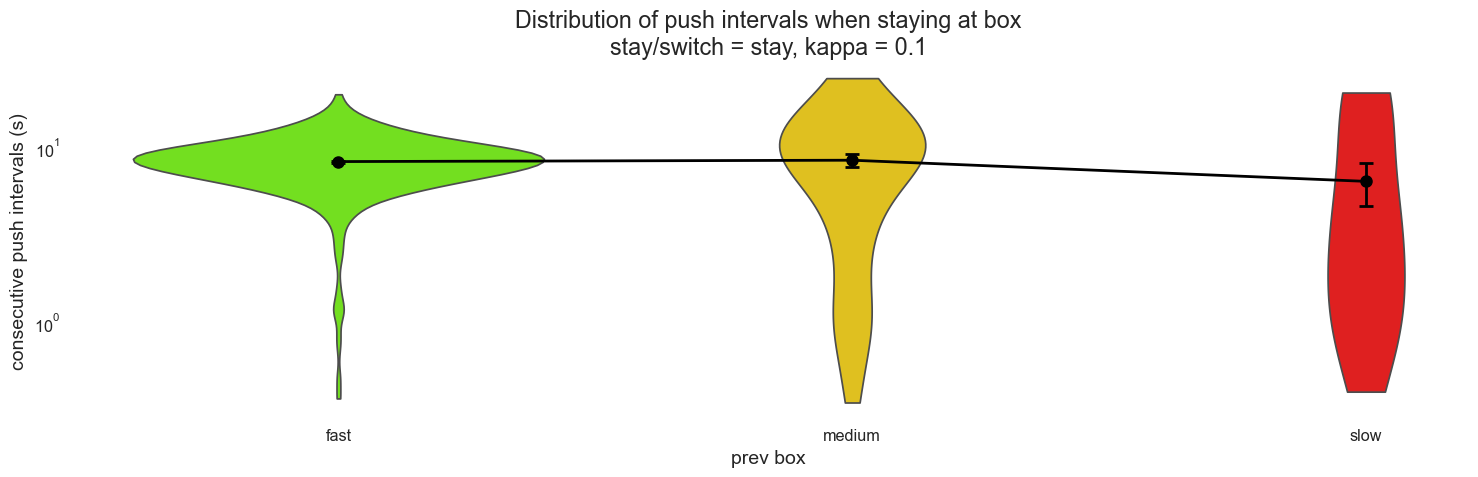

In [61]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
conds = {
    'stay/switch': 'stay',
    'kappa': 0.1
}

bp(enhanced_violinplot)(df, conds = conds, x='prev box', y='consecutive push intervals', hue = 'prev box', palette = dict(zip(BOX_LABELS, BOX_COLORS)), accumulate=True, cut=0,
                   inner=None, common_norm=True, log_scale = True, title_prefix="Distribution of push intervals when staying at box", y_unit = 's', ax=ax, legend = False)

<Axes: title={'center': 'Distribution of push intervals when staying at box\nstay/switch = switch, kappa = 0.1'}, xlabel='prev box', ylabel='consecutive push intervals (s)'>

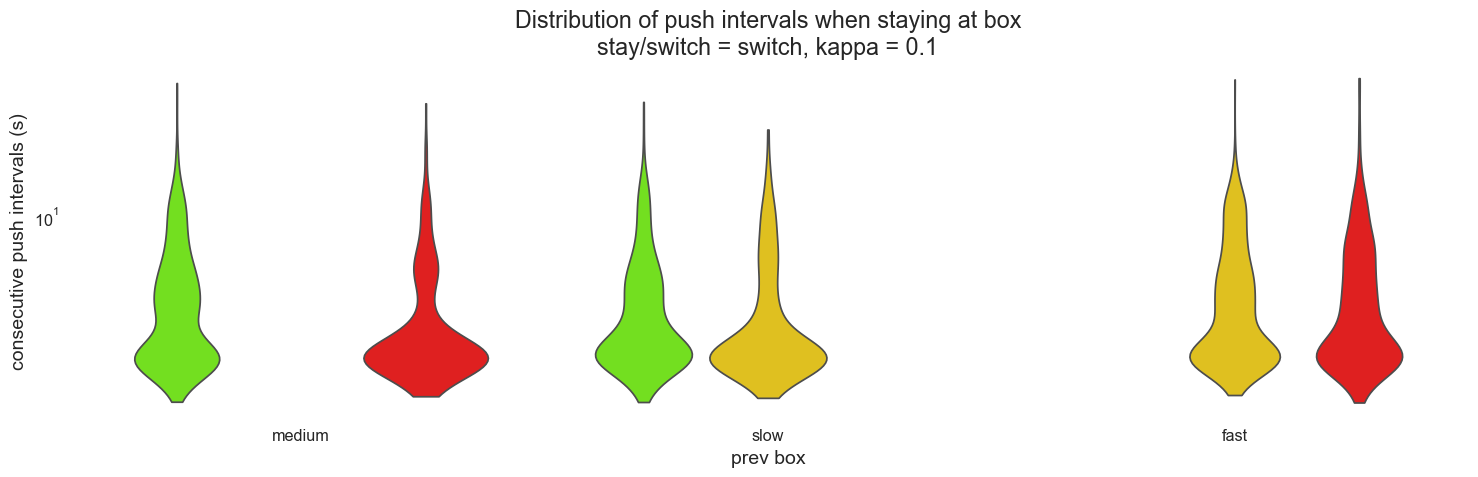

In [63]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
conds = {
    'stay/switch': 'switch',
    'kappa': 0.1
}

bp(sns.violinplot)(df, conds = conds, x='prev box', y='consecutive push intervals', hue = 'box', palette = dict(zip(BOX_LABELS, BOX_COLORS)), accumulate=True, cut=0,
                   inner=None, common_norm=True, log_scale = True, title_prefix="Distribution of push intervals when staying at box", y_unit = 's', ax=ax, legend = False)

# Hypothesis: if the data come from a Hidden Markov Model, the push intervals can be well described by an exponential distribution

In [55]:
from scipy.stats import kstest, expon
from functools import partial

# The MLE of data from an exponential distribution is 1/mean
mle_exp = 1 / df.groupby(['prev box', 'box'])['consecutive push intervals'].mean()
prev_boxes = df.dropna()['prev box'].unique()
next_boxes = df['box'].unique()
p_vals = np.zeros((len(prev_boxes), len(next_boxes)))
for i, prev_box in enumerate(prev_boxes):
    for j, next_box in enumerate(next_boxes):
        push_times = df.loc[(df['prev box'] == prev_box) & (df['box'] == next_box), 'consecutive push intervals']
        p_vals[i,j] = kstest(push_times, cdf = partial(expon.cdf, scale = mle_exp.loc[(prev_box, next_box)])).pvalue
p_vals

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 4.71888911e-233, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000]])

Single box, single decision optimal push time

Text(0, 0.5, '$Q(t) = e^{-\\gamma t}F(t)$')

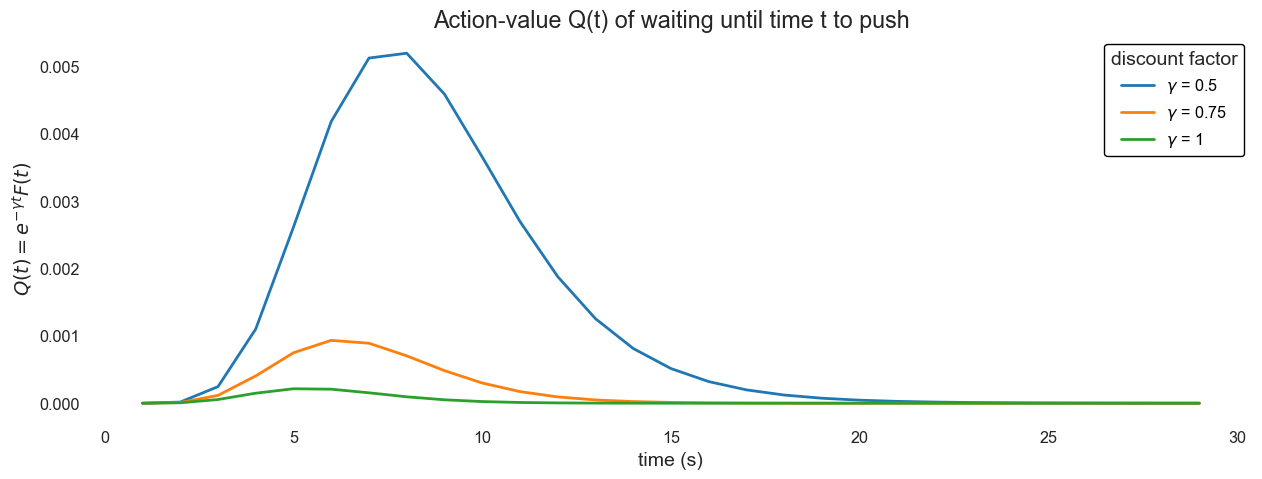

In [81]:
def q_value(discount_factor, t, schedule, alpha = 10):
    return np.exp(-discount_factor*t) * gamma.cdf(t, a = alpha, scale = schedule / alpha)

ts = np.arange(1, 30)
discounts = [0.5, 0.75, 1]
schedule = 10
for discount in discounts:
    ys = q_value(discount, ts, schedule)
    plt.plot(ts, ys, label = rf'$\gamma$ = {discount}')
plt.legend(title = 'discount factor')
plt.title(r"Action-value Q(t) of waiting until time t to push")
plt.xlabel('time (s)')
plt.ylabel(r'$Q(t) = e^{-\gamma t}F(t)$')

# Hidden Semi-Markov Model
The time between pushes are log-normal


# Simple Policy

In [40]:
N = 1000 # n steps in env
N_BOXES = 3
thresholds = np.linspace(0.1, 1, 5, endpoint = False)
# thresholds = [0.1]
box_states = np.zeros(N_BOXES)
elapsed_time = np.zeros_like(box_states)
schedules = [7, 14, 21]
average_reward_global = np.zeros(len(thresholds))
average_reward_local = np.zeros((len(thresholds), N_BOXES))
reward_rates_global = np.zeros(len(thresholds))
reward_rates_local = np.zeros((len(thresholds), N_BOXES))
discounts = np.linspace(0, 1, 5)
discounted_reward_global = np.zeros((len(discounts), len(thresholds)))
discounted_reward_local = np.zeros((len(discounts), len(thresholds), N_BOXES))
past_window_times =[[]] * N_BOXES

# Pick threshold
reward_history = [[]] * len(thresholds)
for thresh_i, thresh in enumerate(thresholds):
    push_ts = np.array([gamma.ppf(thresh, a = 10, scale = schedules[i] / 10) for i in range(N_BOXES)])

    # Init boxes
    for i in range(N_BOXES):
        box_states[i] = gamma.rvs(a = 10, scale = schedules[i] / 10)

    n_visits_by_box = [[]] * N_BOXES
    timer = np.zeros(N_BOXES)
    total_time = 0
    for i in range(1, N+1):
        pick_i = np.argmin(timer + push_ts) #todo: handle tie breaker
        pick_t = (timer + push_ts)[pick_i]
        r = 0
        if box_states[pick_i] <= pick_t:
            r = 1
        average_reward_global[thresh_i] += 1/i *(r - average_reward_global[thresh_i])
        reward_history[thresh_i].append(average_reward_global[thresh_i])
        total_time = pick_t
        timer[pick_i] = pick_t
        box_states[pick_i] = pick_t + gamma.rvs(a = 10, scale = schedules[pick_i] / 10)
        print(elapsed_time, box_states, pick_i, pick_t, thresh)


[0. 0. 0.] [12.32470836 17.23866326 25.02316459] 0 4.354913223657522 0.1
[0. 0. 0.] [16.66504398 17.23866326 25.02316459] 0 8.709826447315043 0.1
[0. 0. 0.] [16.66504398 19.87574023 25.02316459] 1 8.709826447315043 0.1
[0. 0. 0.] [21.36913545 19.87574023 25.02316459] 0 13.064739670972564 0.1
[0. 0. 0.] [21.36913545 19.87574023 24.61909298] 2 13.064739670972566 0.1
[0. 0. 0.] [24.1609789  19.87574023 24.61909298] 0 17.419652894630087 0.1
[0. 0. 0.] [24.1609789  36.8914074  24.61909298] 1 17.419652894630087 0.1
[0. 0. 0.] [30.00396294 36.8914074  24.61909298] 0 21.77456611828761 0.1
[0. 0. 0.] [30.00396294 35.40549041 24.61909298] 1 26.129479341945128 0.1
[0. 0. 0.] [32.41221352 35.40549041 24.61909298] 0 26.12947934194513 0.1
[0. 0. 0.] [32.41221352 35.40549041 46.75792021] 2 26.12947934194513 0.1
[0. 0. 0.] [40.72107496 35.40549041 46.75792021] 0 30.484392565602654 0.1
[0. 0. 0.] [45.98271212 35.40549041 46.75792021] 0 34.83930578926017 0.1
[0. 0. 0.] [45.98271212 54.64261036 46.757920

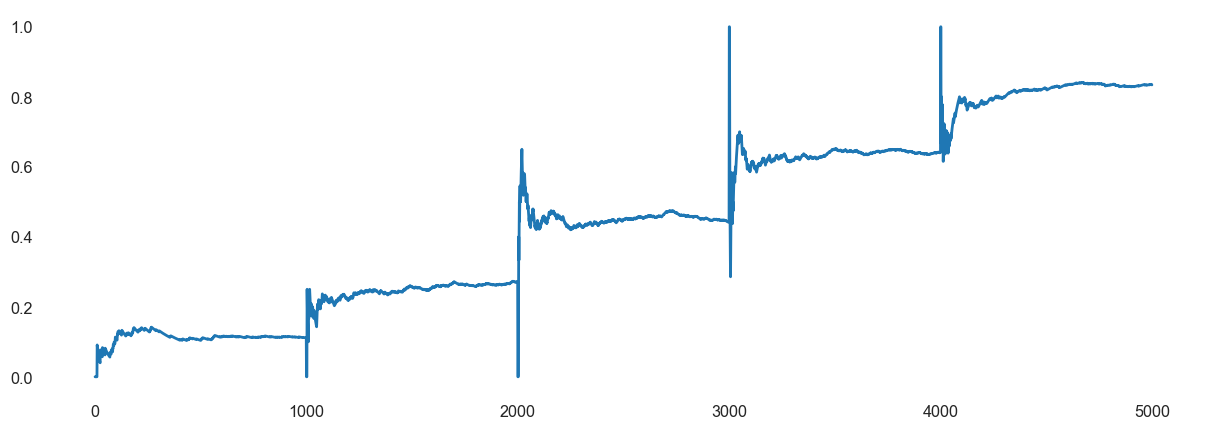

In [42]:
plt.plot(np.array(reward_history[0]).T)

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import Generator, PCG64

# --- Simulation Code ---
def simulate_agent(N=1000, N_sims = 100, seeds = None, shape_param=10.0, means=[7, 14, 21], thresholds=[0.5, 0.6, 0.7, 0.8, 0.9], discount_rates=[0.01, 0.05, 0.1]):
    if seeds is None:
        seeds = np.arange(N_sims)
    scales = [m / shape_param for m in means]
    n_boxes = len(means)
    dfs = []
    for sim in tqdm(range(N_sims)):
        gamma.random_state = Generator(PCG64(seeds[sim]))
        for threshold in thresholds:
            log = []
            boxes = []
            for i in range(n_boxes):
                reward_interval = gamma.rvs(shape_param, scale=scales[i])
                boxes.append({
                    'last_push_time': 0.0,
                    'reward_time': reward_interval,
                    'shape': shape_param,
                    'scale': scales[i],
                    'threshold': threshold
                })

            for step in range(N):
                next_push_times = []
                for i, box in enumerate(boxes):
                    t_since_last = gamma.ppf(box['threshold'], box['shape'], scale=box['scale'])
                    next_push_time = box['last_push_time'] + t_since_last
                    next_push_times.append((next_push_time, i))

                next_push_times.sort()
                soonest_time, _ = next_push_times[0]
                reward_obtained = 0
                pushed_box = []
                rts= []
                for pt, i in next_push_times:
                    if np.isclose(pt, soonest_time, atol = 0):
                        reward_obtained += soonest_time >= boxes[i]['reward_time']
                        rts.append(boxes[i]['reward_time'])
                        new_interval = gamma.rvs(boxes[i]['shape'], scale=boxes[i]['scale'])
                        boxes[i]['last_push_time'] = soonest_time
                        boxes[i]['reward_time'] = soonest_time + new_interval
                        pushed_box.append(i)

                time = soonest_time
                log.append({
                    'time': time,
                    'reward': int(reward_obtained),
                    'threshold': threshold,
                    'boxes': pushed_box,
                    'reward_times': rts,
                    'sim': sim
                })

            df_run = pd.DataFrame(log)
            df_run['cumulative_reward'] = df_run['reward'].cumsum()
            df_run['reward_rate'] = df_run['cumulative_reward'] / (df_run['time'] + 1e-8)
            for gamma_ in discount_rates:
                discounts = np.exp(-gamma_ * df_run['time'])
                discounted_reward = (df_run['reward'] * discounts).cumsum()
                df_run[f'discounted_reward_gamma_{gamma_}'] = discounted_reward
            dfs.append(df_run)
    return pd.concat(dfs)

# --- Run the simulation ---
df = simulate_agent()

100%|██████████| 100/100 [02:07<00:00,  1.28s/it]


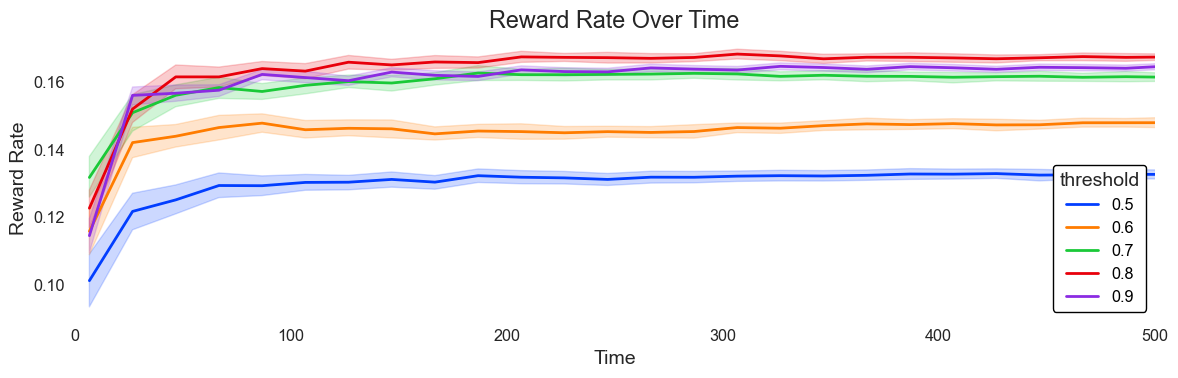

In [148]:
plt.figure(figsize=(12, 4))
df['time bins'] = bin_data(df, 'time', bin_width=20)
sns.lineplot(x='time bins', y='reward_rate', hue = 'threshold', data=df, palette = 'bright')
plt.title("Reward Rate Over Time")
plt.xlabel("Time")
plt.ylabel("Reward Rate")
# plt.grid(True)
plt.xlim([0, 500])
plt.tight_layout()
plt.show()

In [164]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma

def plot_trajectory(df, box_id=0, steps_to_plot=5, means=[7, 14, 21], shape = 10, box_colors = BOX_COLORS):
    """
    Visualize reward probability trajectory for a given box_id, accounting for multiple boxes being pushed at once.
    """
    scale = means[box_id] / shape

    fig, ax = plt.subplots(figsize=(10, 6))

    # Track last push time for the box of interest
    last_push_time = 0
    count = 0
    probs_all = []
    ts_all = []
    label_flags = [0,0]
    for _, row in df.iterrows():
        if box_id not in row['boxes']:
            continue  # skip events that don't involve this box

        push_time = row['time']
        i = row['boxes'].index(box_id)
        reward_time = row['reward_times'][i]
        rewarded = reward_time <= push_time

        # Time points for plotting the reward probability curve
        ts = np.linspace(last_push_time, push_time, 200)
        probs = gamma.cdf(ts - last_push_time, shape, scale=scale)
        probs_all.append(probs)
        ts_all.append(ts)

        # Vertical line at reward delivery
        if rewarded:
            ax.axvline(reward_time, color='red', label='Reward time (rewarded)' if label_flags[0] == 0 else None)
            label_flags[0] = 1
        else:
            ax.axvline(reward_time, color='blue', label='Reward time (not rewarded)' if label_flags[1] == 0 else None)
            label_flags[1] = 1

        # # Vertical line at push time
        # ax.axvline(push_time, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Push time' if count == 0 else None)

        # Optional: show threshold line
        threshold = row['threshold']

        last_push_time = push_time
        count += 1
        if count >= steps_to_plot:
            break

    # Plot reward probability curve
    ax.plot(np.concatenate(ts_all), np.concatenate(probs_all), color=box_colors[box_id], label='Reward probability')
    ax.hlines(threshold, 0, last_push_time, color='gray', linestyle=':', alpha=0.4, label = 'threshold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Time")
    ax.set_ylabel("Reward Probability")
    ax.set_title(f"Trajectory for Box {box_id}")
    # ax.legend()
    plt.tight_layout()
    plt.show()
    return ax


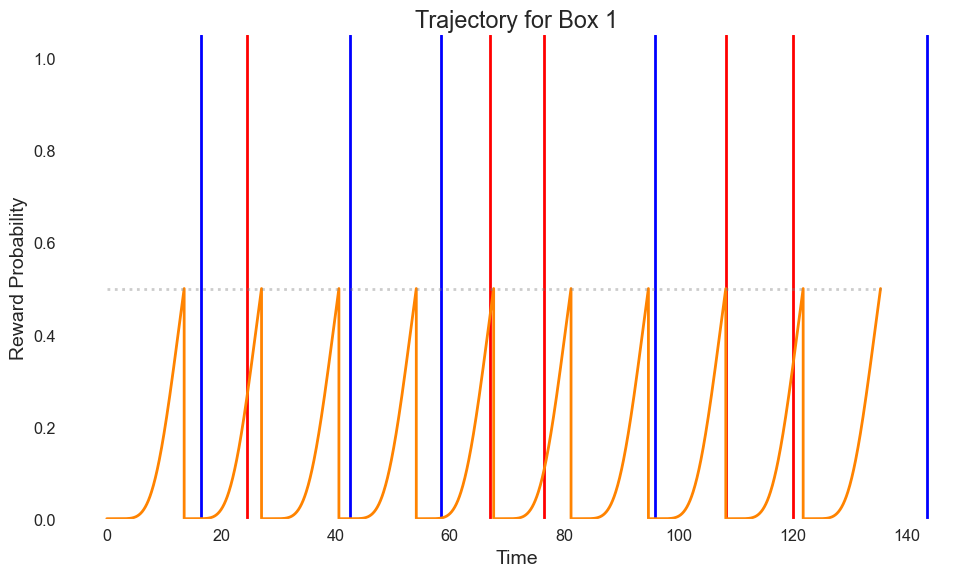

In [165]:
ax = plot_trajectory(df[(df['threshold'] == 0.5) & (df['sim'] == 0)], box_id=1, steps_to_plot=10)

In [150]:
df[(df['threshold'] == 0.5) & (df['sim'] == 0)]

,time,reward,threshold,boxes,reward_times,sim,cumulative_reward,reward_rate,discounted_reward_gamma_0.01,discounted_reward_gamma_0.05,discounted_reward_gamma_0.1,time bins
0,6.768100,0,0.5,[0],[7.044009594641757],0,0,0.000000,0.000000,0.000000,0.000000,6.767
1,13.536200,0,0.5,"[0, 1]","[16.788030940620867, 16.516729983023062]",0,0,0.000000,0.000000,0.000000,0.000000,6.767
2,20.304301,2,0.5,"[0, 2]","[18.88391646844268, 16.99954017099173]",0,2,0.098501,1.632486,0.724649,0.262558,6.767
3,27.072401,2,0.5,"[0, 1]","[23.167338129813665, 24.53380763147598]",0,4,0.147752,3.158140,1.241256,0.395999,26.768
4,33.840501,1,0.5,[0],[32.72232177104926],0,5,0.147752,3.871047,1.425402,0.429909,26.768
...,...,...,...,...,...,...,...,...,...,...,...,...
995,6741.027829,1,0.5,"[0, 1, 2]","[6744.796596888249, 6738.4875962158985, 6749.2...",0,919,0.136329,13.841361,2.029577,0.483927,6726.768
996,6747.795930,0,0.5,[0],[6749.223071420434],0,919,0.136193,13.841361,2.029577,0.483927,6746.768
997,6754.564030,1,0.5,"[0, 1]","[6752.640062184071, 6754.571824976669]",0,920,0.136204,13.841361,2.029577,0.483927,6746.768
998,6761.332130,1,0.5,"[0, 2]","[6763.379821359115, 6755.862277482718]",0,921,0.136216,13.841361,2.029577,0.483927,6746.768


## Noisy Observation

In [132]:
def compute_next_push_time(last_push, reward_time, threshold, scale, noise_sd, shape = 10):
    # Noisy internal estimate
    noisy_estimate = reward_time + np.random.normal(0, noise_sd)
    est_time = max(0, noisy_estimate) + 1 # add bias since it makes sense to push after estimated reward interval

    # Threshold-based time
    thresh_time = last_push + gamma.ppf(threshold, shape, scale = scale)
    return 1/(noise_sd**2 + 1) * est_time + (1 - 1/(noise_sd**2 + 1)) * thresh_time

def simulate_agent_noisy_obs(N=1000, N_sims = 100, seeds = None, shape_param=10.0, means=[7, 14, 21], thresholds=[0.5, 0.6, 0.7, 0.8, 0.9], discount_rates=[0.01, 0.05, 0.1], noise_sds = [0.01, 0.1, 0.5, 1]):
    if seeds is None:
        seeds = np.arange(N_sims)
    scales = [m / shape_param for m in means]
    n_boxes = len(means)
    dfs = []
    for sim in tqdm(range(N_sims)):
        gamma.random_state = Generator(PCG64(seeds[sim]))
        for noise_sd in noise_sds:
            for threshold in thresholds:
                log = []
                boxes = []
                for i in range(n_boxes):
                    reward_interval = gamma.rvs(shape_param, scale=scales[i])
                    boxes.append({
                        'last_push_time': 0.0,
                        'reward_time': reward_interval,
                        'shape': shape_param,
                        'scale': scales[i],
                        'threshold': threshold
                    })

                for step in range(N):
                    next_push_times = []
                    for i, box in enumerate(boxes):
                        next_push_time = compute_next_push_time(box['last_push_time'], box['reward_time'], box['threshold'], box['scale'], noise_sd, shape = box['shape'])
                        next_push_times.append((next_push_time, i))

                    next_push_times.sort()
                    soonest_time, _ = next_push_times[0]
                    reward_obtained = 0
                    pushed_box = []
                    rts= []
                    for pt, i in next_push_times:
                        if np.isclose(pt, soonest_time, atol = 0):
                            reward_obtained += soonest_time >= boxes[i]['reward_time']
                            rts.append(boxes[i]['reward_time'])
                            new_interval = gamma.rvs(boxes[i]['shape'], scale=boxes[i]['scale'])
                            boxes[i]['last_push_time'] = soonest_time
                            boxes[i]['reward_time'] = soonest_time + new_interval
                            pushed_box.append(i)

                    time = soonest_time
                    log.append({
                        'time': time,
                        'reward': int(reward_obtained),
                        'threshold': threshold,
                        'noise_sd': noise_sd,
                        'boxes': pushed_box,
                        'reward_times': rts,
                        'sim': sim
                    })

                df_run = pd.DataFrame(log)
                df_run['cumulative_reward'] = df_run['reward'].cumsum()
                df_run['reward_rate'] = df_run['cumulative_reward'] / (df_run['time'] + 1e-8)
                for gamma_ in discount_rates:
                    discounts = np.exp(-gamma_ * df_run['time'])
                    discounted_reward = (df_run['reward'] * discounts).cumsum()
                    df_run[f'discounted_reward_gamma_{gamma_}'] = discounted_reward
                dfs.append(df_run)
    return pd.concat(dfs)

# --- Run the simulation ---
df = simulate_agent_noisy_obs(N = 500, thresholds = [0.5, 0.8])

100%|██████████| 100/100 [01:40<00:00,  1.01s/it]


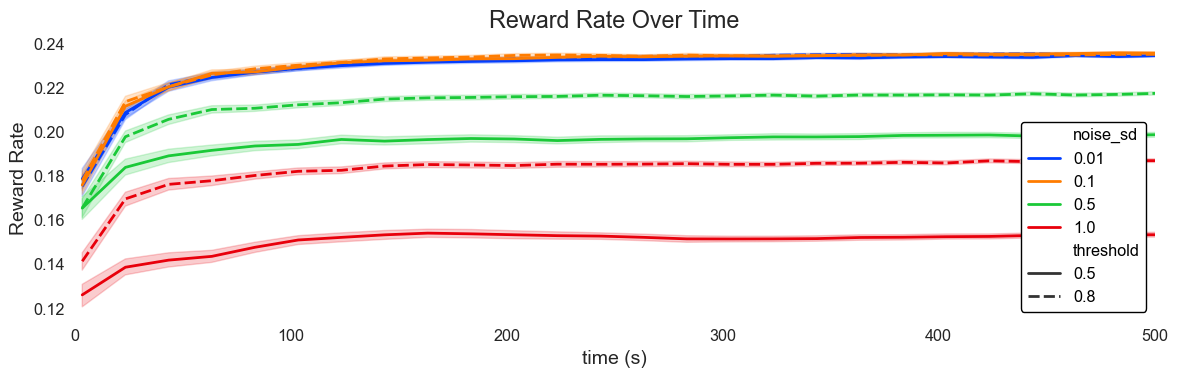

In [133]:
from foraging.utils.data import bin_data
plt.figure(figsize=(12, 4))
df['time bins'] = bin_data(df, 'time', bin_width=20)
sns.lineplot(x='time bins', y='reward_rate', hue = 'noise_sd', data=df, style = 'threshold', palette = 'bright')
plt.title("Reward Rate Over Time")
plt.xlabel("time (s)")
plt.ylabel("Reward Rate")
# plt.grid(True)
plt.xlim([0, 500])
plt.tight_layout()
plt.show()

In [138]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma

def plot_trajectory2(df, box_id=0, steps_to_plot=5, means=[7, 14, 21], shape = 10, box_colors = BOX_COLORS):
    """
    Visualize reward probability trajectory for a given box_id, accounting for multiple boxes being pushed at once.
    """
    scale = means[box_id] / shape

    fig, ax = plt.subplots(figsize=(10, 6))

    # Track last push time for the box of interest
    last_push_time = 0
    count = 0
    probs_all = []
    ts_all = []
    label_flags = [0,0]
    for _, row in df.iterrows():
        if box_id not in row['boxes']:
            continue  # skip events that don't involve this box

        push_time = row['time']
        i = row['boxes'].index(box_id)
        reward_time = row['reward_times'][i]
        rewarded = reward_time <= push_time

        # Time points for plotting the reward probability curve
        ts = np.linspace(last_push_time, push_time, 200)
        probs = gamma.cdf(ts - last_push_time, shape, scale=scale)
        probs_all.append(probs)
        ts_all.append(ts)

        # Vertical line at reward delivery
        if rewarded:
            ax.axvline(reward_time, color='green', label='Reward time (rewarded)' if label_flags[0] == 0 else None)
            label_flags[0] = 1
        else:
            ax.axvline(reward_time, color='red', label='Reward time (not rewarded)' if label_flags[1] == 0 else None)
            label_flags[1] = 1

        # # Vertical line at push time
        ax.axvline(push_time, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Push time' if count == 0 else None)

        # Optional: show threshold line
        threshold = row['threshold']

        last_push_time = push_time
        count += 1
        if count >= steps_to_plot:
            break

    # Plot reward probability curve
    ax.plot(np.concatenate(ts_all), np.concatenate(probs_all), color=box_colors[box_id], label='Reward probability')
    ax.hlines(threshold, 0, last_push_time, color='gray', linestyle=':', alpha=0.4, label = 'threshold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Time")
    ax.set_ylabel("Reward Probability")
    ax.set_title(f"Trajectory for Box {box_id}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return ax


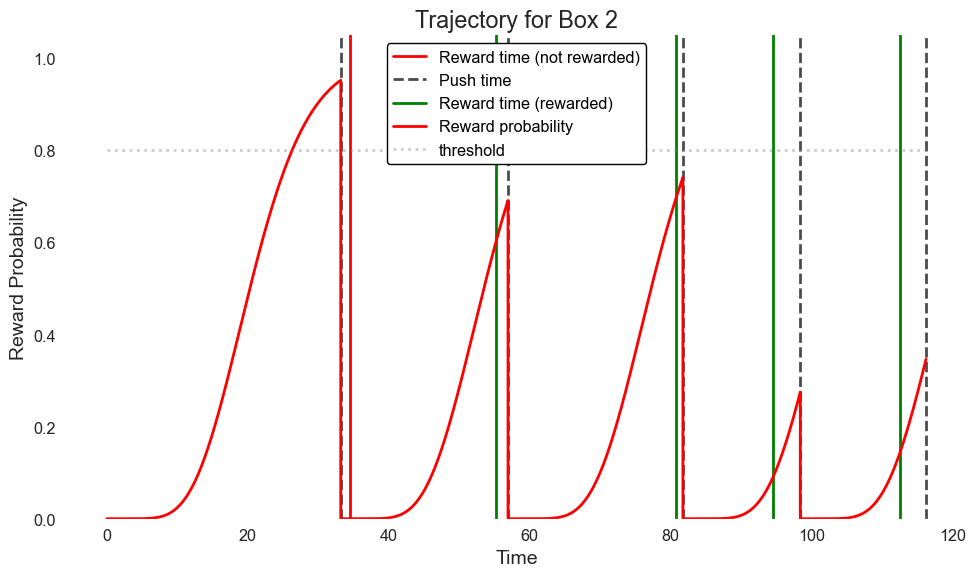

In [142]:
ax = plot_trajectory2(df[(df['threshold'] == 0.8) & (df['noise_sd'] == 0.5) & (df['sim'] == 0)], box_id=2, steps_to_plot=5)

In [145]:
# todo: sim where fast box is pushed according to threshold of 0.8, but other two boxes the threshold is allowed to vary
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import Generator, PCG64

# --- Simulation Code ---
def simulate_agent_vary_threshold(N=1000, N_sims = 100, seeds = None, shape_param=10.0, means=[7, 14, 21], thresholds=[(0.5, 0.4), (0.7, 0.6)], discount_rates=[0.01, 0.05, 0.1]):
    if seeds is None:
        seeds = np.arange(N_sims)
    scales = [m / shape_param for m in means]
    n_boxes = len(means)
    dfs = []
    for sim in tqdm(range(N_sims)):
        gamma.random_state = Generator(PCG64(seeds[sim]))
        for threshold in thresholds:
            log = []
            boxes = []
            for i in range(n_boxes):
                reward_interval = gamma.rvs(shape_param, scale=scales[i])
                if i == 0:
                    boxes.append({
                        'last_push_time': 0.0,
                        'reward_time': reward_interval,
                        'shape': shape_param,
                        'scale': scales[i],
                        'threshold': 0.8
                    })
                else:
                    boxes.append({
                        'last_push_time': 0.0,
                        'reward_time': reward_interval,
                        'shape': shape_param,
                        'scale': scales[i],
                        'threshold': threshold[i-1]
                    })

            for step in range(N):
                next_push_times = []
                for i, box in enumerate(boxes):
                    t_since_last = gamma.ppf(box['threshold'], box['shape'], scale=box['scale'])
                    next_push_time = box['last_push_time'] + t_since_last
                    next_push_times.append((next_push_time, i))

                next_push_times.sort()
                soonest_time, _ = next_push_times[0]
                reward_obtained = 0
                pushed_box = []
                rts= []
                for pt, i in next_push_times:
                    if np.isclose(pt, soonest_time, atol = 0):
                        reward_obtained += soonest_time >= boxes[i]['reward_time']
                        rts.append(boxes[i]['reward_time'])
                        new_interval = gamma.rvs(boxes[i]['shape'], scale=boxes[i]['scale'])
                        boxes[i]['last_push_time'] = soonest_time
                        boxes[i]['reward_time'] = soonest_time + new_interval
                        pushed_box.append(i)

                time = soonest_time
                log.append({
                    'time': time,
                    'reward': int(reward_obtained),
                    'threshold': threshold,
                    'boxes': pushed_box,
                    'reward_times': rts,
                    'sim': sim
                })

            df_run = pd.DataFrame(log)
            df_run['cumulative_reward'] = df_run['reward'].cumsum()
            df_run['reward_rate'] = df_run['cumulative_reward'] / (df_run['time'] + 1e-8)
            for gamma_ in discount_rates:
                discounts = np.exp(-gamma_ * df_run['time'])
                discounted_reward = (df_run['reward'] * discounts).cumsum()
                df_run[f'discounted_reward_gamma_{gamma_}'] = discounted_reward
            dfs.append(df_run)
    return pd.concat(dfs)

# --- Run the simulation ---
df = simulate_agent_vary_threshold()

100%|██████████| 100/100 [00:51<00:00,  1.94it/s]


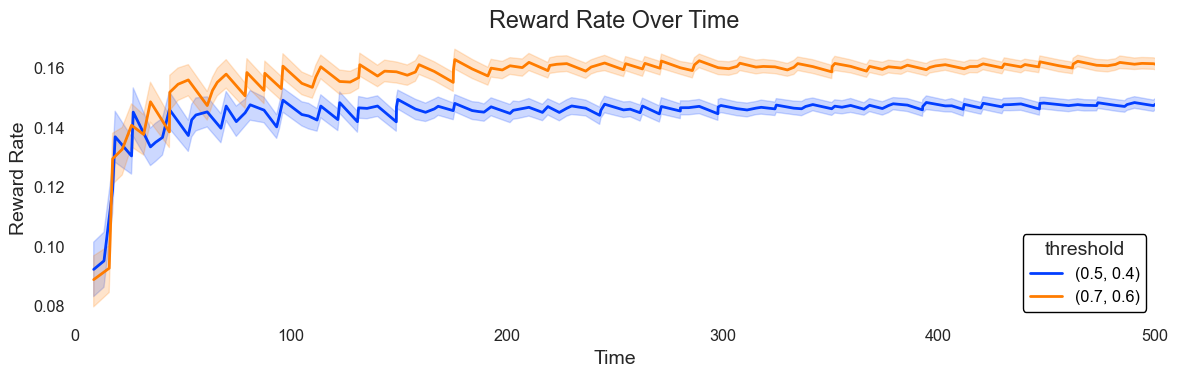

In [146]:
plt.figure(figsize=(12, 4))
sns.lineplot(x='time', y='reward_rate', hue = 'threshold', data=df, palette = 'bright')
plt.title("Reward Rate Over Time")
plt.xlabel("Time")
plt.ylabel("Reward Rate")
# plt.grid(True)
plt.xlim([0, 500])
plt.tight_layout()
plt.show()

In [ ]:
rhos = np.linspace(0, 1, 5, endpoint = False)
sigma_corrs = np.linspace(0.01, 1, 50)
sigma_inds = []
for rho in rhos:
    sigma_ind = sigma_corrs/(1-rho)**2
    plt.plot(sigma_corrs, sigma_ind, label = rho)
plt.legend(title = r'$\rho$')
plt.xlabel(r'$\sigma^2_{\text{corr}}$')
plt.ylabel(r'$\sigma^2_{\text{ind}}$')
plt.title(r"$I_{\text{ind}} = I_{\text{corr}}$")
plt.ylim([0, sigma_corrs.max()])

# Fit Models

In [35]:
x = df.index.get_level_values('push #')
consecutive_mask = x[1:] - x[:-1] == 1
# change_mask = (df['stay/switch'] == 'switch') & np.insert(consecutive_mask, 0, True)
change_mask = (df['stay/switch'] == 'switch')
push_nums = utils.data.get_blocks(df)["push times"].rank().astype(
    int)  # Calculate from scratch in case pushes got dropped
change_mask[push_nums == 1] = True

# Count the runlengths at different boxes
group_labels = change_mask.cumsum()
labeled_lengths = pd.DataFrame(
    {"group": group_labels, "box": df['box'], 'push times': df['push times']}
).set_index(df.index)
stay_time = labeled_lengths.groupby('group').last()['push times'] - labeled_lengths.groupby('group').first()['push times']
# labeled_lengths_all = labeled_lengths.groupby(['subject', 'kappa', 'box', 'group']).size().to_frame().rename(
#     columns={0: 'length'})
len(labeled_lengths), len(stay_time)
# labeled_lengths_all = labeled_lengths_all[
#     (labeled_lengths_all['length'] > 1) & (labeled_lengths_all['length'] <= 10)]
#
# # Calculate the distribution of runlengths
visit_freqs = df.groupby(['subject', 'kappa'])['box'].value_counts(normalize=True).to_frame()

In [36]:
def stay_switch(df_session):
    return pd.crosstab(df_session['prev_box1'].values.squeeze(), df_session['curr_box'].values.squeeze(), normalize='index')

curr_box = df["box rank"].shift(0)
prev_box1 = df["box rank"].shift(1)
prev_box2 = df["box rank"].shift(2)
ro_1 = df["reward outcomes"].shift(1)
ro_2 = df["reward outcomes"].shift(2)

# 1st order markov chain + stay/switch
filter_idx = (df.index.get_level_values('push #') != pd.Series(df.index.get_level_values('push #')).shift(1) + 1)
prev_box1.loc[filter_idx] = np.nan
ro_1[filter_idx] = np.nan
filter_idx = get_blocks(df).head(1).index
prev_box1.loc[filter_idx] = np.nan
ro_1[filter_idx] = np.nan

transitions_ss = pd.DataFrame({'curr_box': curr_box, 'prev_box1': prev_box1}).set_index(df.index)
trans_mat = pd.crosstab(transitions_ss['prev_box1'].values.squeeze(), transitions_ss['curr_box'].values.squeeze(), normalize='index')

                    proportion
subject kappa box             
viktor  0.01  slow    0.268944


In [55]:
df['push freqs'] = df['same-box push intervals'].transform(lambda x: x**-1)
push_rates = df.groupby(by=['subject', 'kappa', 'box rank'])['push freqs'].mean()
print(filter_df(push_rates, conds = conds_2).iloc[0])

0.5204568250469737


In [56]:
from collections import defaultdict
conds_1 = dict(subject='viktor', kappa=0.01)
conds_2 = {k: v for k,v in conds_1.items()}
T = 300
# Sample uniformly from length column of labeled_lengths
# This is the dwell time at a box
# Randomly sample box from visit_freqs
# Repeat T times

RNG = np.random.default_rng(SEED)
boxes = sorted(df['box rank'].unique())
box = RNG.choice(boxes, p=filter_df(visit_freqs, conds_1)['proportion'])
dwells = defaultdict(list)
n_pushes = defaultdict(list)
for t in range(T):
    conds_2['box rank'] = box
    subj_runs = filter_df(labeled_lengths, conds_2)
    stay_time = subj_runs.groupby('group').last()['push times'] - subj_runs.groupby('group').first()['push times']
    dwell = RNG.choice(stay_time)
    dwells[box].append(dwell)
    n_pushes[box].append(RNG.poisson(dwell * filter_df(push_rates, conds = conds_2).iloc[0]))
    trans_mat = pd.crosstab(filter_df(transitions_ss, conds_1)['prev_box1'].values.squeeze(), filter_df(transitions_ss, conds_1)['curr_box'].values.squeeze(), normalize='index')
    other_boxes = [b for b in boxes if b != box]
    p = trans_mat.loc[box][boxes != box]
    p /= p.sum()
    box = RNG.choice(other_boxes, p=p)

In [362]:
# K-fold cross-validation
k = 10
utils.stats.kfold_kappa(df_monkey, k, seed = SEED)

In [365]:
print(df_monkey['1-fold'])

subject  session  block  push #  stimulus type  shape  kappa  week day
dylan    1        2      1       probability    1      0.1    M           train
                         2       probability    1      0.1    M           train
                         3       probability    1      0.1    M           train
                         4       probability    1      0.1    M            test
                         5       probability    1      0.1    M           train
                                                                          ...  
viktor   41       10     116     availability   10     0.1    R           train
                         117     availability   10     0.1    R           train
                         118     availability   10     0.1    R           train
                         119     availability   10     0.1    R           train
                         120     availability   10     0.1    R           train
Name: 1-fold, Length: 139739, dtype: object


In [48]:
null_train, null_test = utils.stats.kfold_fit_eval(df_monkey, k, lambda df, **kwargs: None, lambda df, params, **kwargs: utils.data.process_blocks(df, utils.stats.null_likelihood)[0], fit_name = 'null')

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f802af53460>>
Traceback (most recent call last):
  File "/home/nquazi/miniconda3/envs/xaqlab/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

In [353]:
biased_coin_train, biased_coin_test = utils.stats.kfold_fit_eval(df_monkey, k, lambda df, **kwargs: df.groupby(['subject', 'kappa'])['box label'].value_counts(normalize=True).to_frame(), lambda df, params, **kwargs: utils.data.process_blocks(df, utils.stats.biased_coin_likelihood, params)[0], fit_name='biased coin')

In [367]:
utils.stats.biased_coin_likelihood(df.groupby(['subject', 'kappa'])['box label'].value_counts(normalize=True).to_frame())

proportion
subject kappa box label            
dylan   0.01  medium       0.359286
              fast         0.345317
              slow         0.295397
        0.04  fast         0.362142
              medium       0.354839
...                             ...
viktor  0.10  medium       0.325123
              slow         0.246657
        0.20  fast         0.426228
              medium       0.318393
              slow         0.255379

[78 rows x 1 columns]

In [50]:
%%capture --no-display
def stay_switch(df_session):
    return pd.crosstab(df_session['prev_box1'].values.squeeze(), df_session['curr_box'].values.squeeze(), normalize='index')

curr_box = df_monkey["box rank"].shift(0)
prev_box1 = df_monkey["box rank"].shift(1)
prev_box2 = df_monkey["box rank"].shift(2)
ro_1 = df_monkey["reward outcomes"].shift(1)
ro_2 = df_monkey["reward outcomes"].shift(2)

# 1st order markov chain + stay/switch
filter_idx = (df_monkey.index.get_level_values('push #') != pd.Series(df_monkey.index.get_level_values('push #')).shift(1) + 1)
prev_box1.loc[filter_idx] = np.nan
ro_1[filter_idx] = np.nan
filter_idx = utils.data.get_blocks(df_monkey).head(1).index
prev_box1.loc[filter_idx] = np.nan
ro_1[filter_idx] = np.nan

transitions_ss = pd.DataFrame({'curr_box': curr_box, 'prev_box1': prev_box1}).set_index(df_monkey.index)
# transitions_ss_sessions = transitions_ss.groupby(['subject', 'session']).apply(stay_switch)

stayswitch_train, stayswitch_test = utils.stats.kfold_fit_eval(df_monkey, k, lambda df, **kwargs: transitions_ss.loc[df.index].groupby(['subject', 'session']).apply(stay_switch), lambda df, params, **kwargs: utils.data.process_blocks(transitions_ss.loc[df.index], utils.stats.stay_switch_likelihood, params)[0], fit_name='stay/switch')

In [355]:
curr_box = df_monkey["box rank"].shift(0)
prev_box1 = df_monkey["box rank"].shift(1)
prev_box2 = df_monkey["box rank"].shift(2)
ro_1 = df_monkey["reward outcomes"].shift(1)
ro_2 = df_monkey["reward outcomes"].shift(2)

def mc_1(df_session):
    transitions = {}
    transitions[False] = pd.crosstab(df_session.loc[df_session['ro_1'] == False, 'prev_box1'].values.squeeze(), df_session.loc[df_session['ro_1'] == False, 'curr_box'].values.squeeze(), normalize='index')
    transitions[True] = pd.crosstab(df_session.loc[df_session['ro_1'] == True, 'prev_box1'].values.squeeze(), df_session.loc[df_session['ro_1'] == True, 'curr_box'].values.squeeze(), normalize='index')
    return transitions

transitions1 = pd.DataFrame({'curr_box': curr_box, 'prev_box1': prev_box1, 'ro_1': ro_1}).set_index(df_monkey.index)
# transitions1_sessions = transitions1.groupby(['subject', 'session']).apply(mc_1)

mc_1st_order_train, mc_1st_order_test = utils.stats.kfold_fit_eval(df_monkey, k, lambda df, **kwargs: transitions1.loc[df.index].groupby(['subject', 'kappa']).apply(mc_1), lambda df, params, **kwargs: utils.data.process_blocks(transitions1.loc[df.index], utils.stats.mc1_likelihood, params)[0], fit_name='1st order MC')

In [361]:
mc_1st_order_train

session id  \
subject session block push # stimulus type shape kappa week day               
dylan   1       2     1      probability   1     0.1   M           20211206   
                      2      probability   1     0.1   M           20211206   
                      3      probability   1     0.1   M           20211206   
                      5      probability   1     0.1   M           20211206   
                      6      probability   1     0.1   M           20211206   
...                                                                     ...   
viktor  41      10    115    availability  10    0.1   R           20230824   
                      116    availability  10    0.1   R           20230824   
                      117    availability  10    0.1   R           20230824   
                      118    availability  10    0.1   R           20230824   
                      120    availability  10    0.1   R           20230824   

                                                                 _session  \
subject session block push # stimulus type shape kappa week day             
dylan   1       2     1      probability   1     0.1   M               20   
                      2      probability   1     0.1   M               20   
                      3      probability   1     0.1   M               20   
                      5      probability   1     0.1   M               20   
                      6      probability   1     0.1   M               20   
...                                                                   ...   
viktor  41      10    115    availability  10    0.1   R               34   
                      116    availability  10    0.1   R               34   
                      117    availability  10    0.1   R               34   
                      118    availability  10    0.1   R               34   
                      120    availability  10    0.1   R               34   

                                                                 schedule  \
subject session block push # stimulus type shape kappa week day             
dylan   1       2     1      probability   1     0.1   M             15.0   
                      2      probability   1     0.1   M             15.0   
                      3      probability   1     0.1   M             15.0   
                      5      probability   1     0.1   M             21.0   
                      6      probability   1     0.1   M             35.0   
...                                                                   ...   
viktor  41      10    115    availability  10    0.1   R             14.0   
                      116    availability  10    0.1   R             14.0   
                      117    availability  10    0.1   R             14.0   
                      118    availability  10    0.1   R             21.0   
                      120    availability  10    0.1   R             21.0   

                                                                 box  \
subject session block push # stimulus type shape kappa week day        
dylan   1       2     1      probability   1     0.1   M           1   
                      2      probability   1     0.1   M           1   
                      3      probability   1     0.1   M           1   
                      5      probability   1     0.1   M           2   
                      6      probability   1     0.1   M           3   
...                                                              ...   
viktor  41      10    115    availability  10    0.1   R           3   
                      116    availability  10    0.1   R           3   
                      117    availability  10    0.1   R           3   
                      118    availability  10    0.1   R           2   
                      120    availability  10    0.1   R           2   

                                                                 push times  \
subject session b

In [322]:
lose = pd.crosstab(transitions1.loc[transitions1['ro_1'] == False, 'prev_box1'].values.squeeze(), transitions1.loc[transitions1['ro_1'] == False, 'curr_box'].values.squeeze(), normalize='index')
win = pd.crosstab(transitions1.loc[transitions1['ro_1'] == True, 'prev_box1'].values.squeeze(), transitions1.loc[transitions1['ro_1'] == True, 'curr_box'].values.squeeze(), normalize='index')

In [321]:
lose

col_0,0,1,2
row_0,,,
0.0,0.629796,0.195038,0.175167
1.0,0.275385,0.522300,0.202315
2.0,0.299061,0.275166,0.425772


Text(219.72222222222223, 0.5, 'From box')

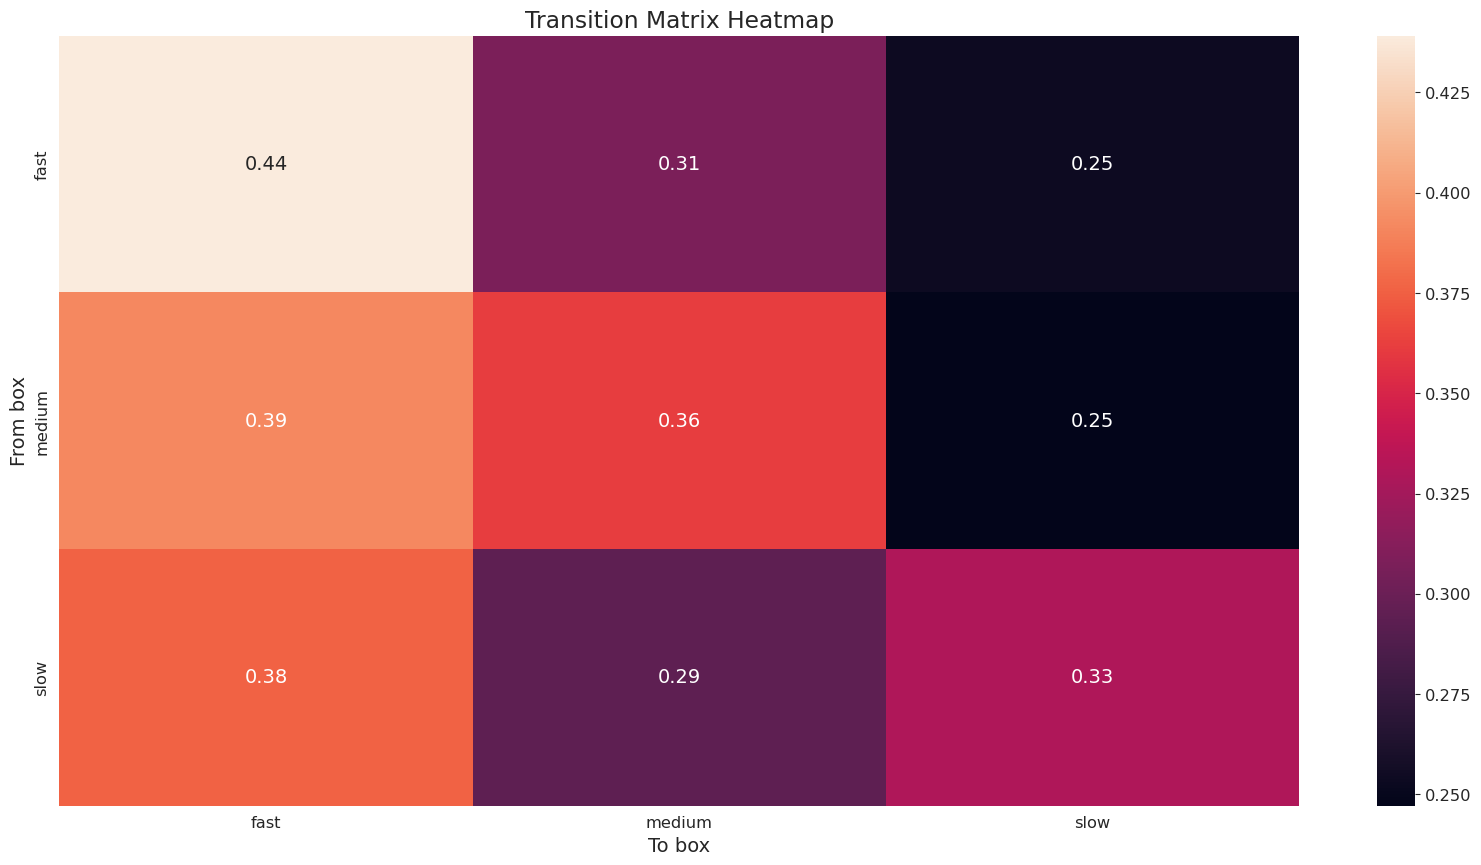

In [323]:
sns.heatmap(
    win,
    cmap = 'rocket',
    annot=True,
    fmt=".2f",
    cbar=True,
    xticklabels=BOX_LABELS,
    yticklabels=BOX_LABELS,
)
plt.title("Transition Matrix Heatmap")
plt.xlabel("To box")
plt.ylabel("From box")


Text(219.72222222222223, 0.5, 'From box')

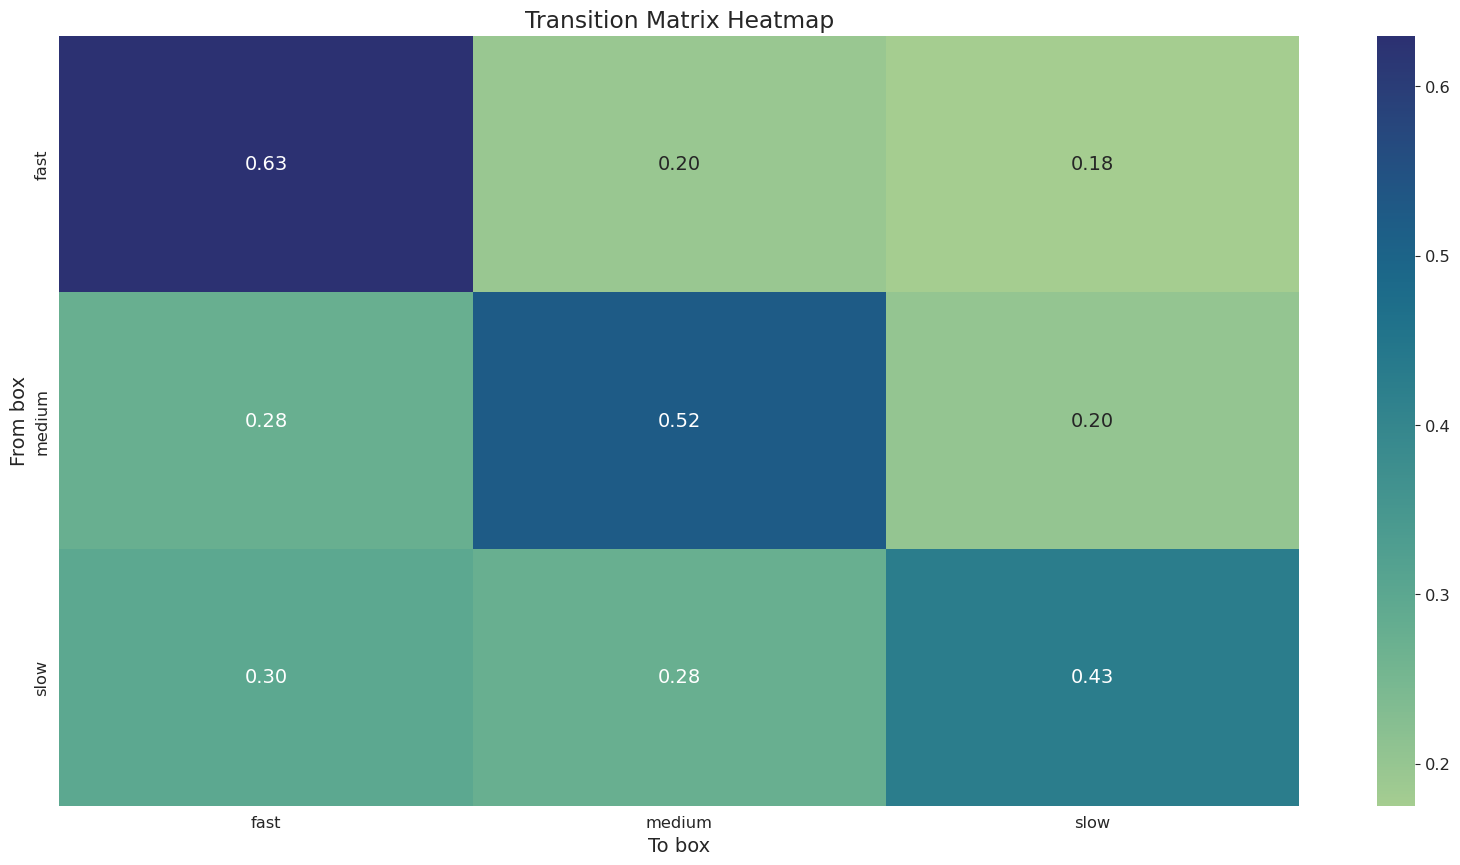

In [326]:
sns.heatmap(
    lose,
    cmap = 'crest',
    annot=True,
    fmt=".2f",
    cbar=True,
    xticklabels=BOX_LABELS,
    yticklabels=BOX_LABELS,
)
plt.title("Transition Matrix Heatmap")
plt.xlabel("To box")
plt.ylabel("From box")


In [52]:
def mc_2(df_session):
    transitions = {}
    try:
        transitions[(False, False)] = pd.crosstab([df_session.loc[(df_session['ro_1'] == False) & (df_session['ro_2'] == False), 'prev_box1'].values.squeeze(), df_session.loc[(df_session['ro_1'] == False) & (df_session['ro_2'] == False), ['prev_box2']].values.squeeze()], df_session.loc[(df_session['ro_1'] == False) & (df_session['ro_2'] == False), 'curr_box'].values.squeeze(), normalize='index')
    except:
        transitions[(False, False)] = pd.DataFrame({'prev_box1': np.tile([0,1,2], reps = 3), 'prev_box2': np.repeat([0,1,2], repeats=3), 0: 1/3*np.ones(9), 1: 1/3*np.ones(9), 2: 1/3*np.ones(9)}).set_index(['prev_box1', 'prev_box2'])
    try:
        transitions[(True, False)] = pd.crosstab([df_session.loc[(df_session['ro_1'] == True) & (df_session['ro_2'] == False), 'prev_box1'].values.squeeze(), df_session.loc[(df_session['ro_1'] == True) & (df_session['ro_2'] == False), ['prev_box2']].values.squeeze()], df_session.loc[(df_session['ro_1'] == True) & (df_session['ro_2'] == False), 'curr_box'].values.squeeze(), normalize='index')
    except:
        transitions[(True, False)] = pd.DataFrame({'prev_box1': np.tile([0,1,2], reps = 3), 'prev_box2': np.repeat([0,1,2], repeats=3), 0: 1/3*np.ones(9), 1: 1/3*np.ones(9), 2: 1/3*np.ones(9)}).set_index(['prev_box1', 'prev_box2'])
    try:
        transitions[(False, True)] = pd.crosstab([df_session.loc[(df_session['ro_1'] == False) & (df_session['ro_2'] == True), ['prev_box1']].values.squeeze(), df_session.loc[(df_session['ro_1'] == False) & (df_session['ro_2'] == True), ['prev_box2']].values.squeeze()], df_session.loc[(df_session['ro_1'] == False) & (df_session['ro_2'] == True), 'curr_box'].values.squeeze(), normalize='index')
    except:
        transitions[(False, True)] = pd.DataFrame({'prev_box1': np.tile([0,1,2], reps = 3), 'prev_box2': np.repeat([0,1,2], repeats=3), 0: 1/3*np.ones(9), 1: 1/3*np.ones(9), 2: 1/3*np.ones(9)}).set_index(['prev_box1', 'prev_box2'])
    try:
        transitions[(True, True)] = pd.crosstab([df_session.loc[(df_session['ro_1'] == True) & (df_session['ro_2'] == True), ['prev_box1']].values.squeeze(), df_session.loc[(df_session['ro_1'] == True) & (df_session['ro_2'] == True), ['prev_box2']].values.squeeze()], df_session.loc[(df_session['ro_1'] == True) & (df_session['ro_2'] == True), 'curr_box'].values.squeeze(), normalize='index')
    except:
        transitions[(True, True)] = pd.DataFrame({'prev_box1': np.tile([0,1,2], reps = 3), 'prev_box2': np.repeat([0,1,2], repeats=3), 0: 1/3*np.ones(9), 1: 1/3*np.ones(9), 2: 1/3*np.ones(9)}).set_index(['prev_box1', 'prev_box2'])
    return transitions

# Check next box actually occurs after this push, otherwise set next box to nan
filter_idx = (df_monkey.index.get_level_values('push #') != pd.Series(df_monkey.index.get_level_values('push #')).shift(1) + 1) | (df_monkey.index.get_level_values('push #') != pd.Series(df_monkey.index.get_level_values('push #')).shift(2) + 2)
prev_box2[filter_idx] = np.nan
ro_2[filter_idx] = np.nan
filter_idx = utils.data.get_blocks(df_monkey).head(2).index
prev_box2[filter_idx] = np.nan
ro_2[filter_idx] = np.nan

transitions2 = pd.DataFrame({'curr_box': curr_box, 'prev_box1': prev_box1, 'prev_box2': prev_box2, 'ro_1': ro_1, 'ro_2': ro_2}).set_index(df_monkey.index)
mc_2nd_order_train, mc_2nd_order_test = utils.stats.kfold_fit_eval(df_monkey, k, lambda df, **kwargs: transitions2.loc[df.index].groupby(['subject', 'session']).apply(mc_2), lambda df, params, **kwargs: utils.data.process_blocks(transitions2.loc[df.index], utils.stats.generalized_markov_likelihood, params)[0], fit_name='2nd order MC')
# transitions2_sessions = transitions2.groupby(['subject', 'session']).apply(mc_2)
# transitions2 = transitions2.reset_index().set_index(['subject', 'session', 'block'])

/mnt/d/Documents/Foraging/src/foraging/utils/stats.py:120: RuntimeWarning: divide by zero encountered in log
  LL[i] = np.log(probs[key].loc[(x['prev_box1'], x['prev_box2']), x['curr_box']])
/mnt/d/Documents/Foraging/src/foraging/utils/stats.py:120: RuntimeWarning: divide by zero encountered in log
  LL[i] = np.log(probs[key].loc[(x['prev_box1'], x['prev_box2']), x['curr_box']])
/mnt/d/Documents/Foraging/src/foraging/utils/stats.py:120: RuntimeWarning: divide by zero encountered in log
  LL[i] = np.log(probs[key].loc[(x['prev_box1'], x['prev_box2']), x['curr_box']])
/mnt/d/Documents/Foraging/src/foraging/utils/stats.py:120: RuntimeWarning: divide by zero encountered in log
  LL[i] = np.log(probs[key].loc[(x['prev_box1'], x['prev_box2']), x['curr_box']])
/mnt/d/Documents/Foraging/src/foraging/utils/stats.py:120: RuntimeWarning: divide by zero encountered in log
  LL[i] = np.log(probs[key].loc[(x['prev_box1'], x['prev_box2']), x['curr_box']])
/mnt/d/Documents/Foraging/src/foraging/utils/

In [358]:
# df_LL = pd.concat([biased_coin_test, stayswitch_test, mc_1st_order_test, mc_2nd_order_test, pd.concat(test_results, axis = 1)], axis = 1)
df_LL = pd.concat([biased_coin_test, mc_1st_order_test, pd.concat(test_results, axis = 1)], axis = 1)
df_LL = df_LL.loc[:, ~df_LL.columns.duplicated()]
try:
    # df_LL.rename(columns={'stay/switch': 'stay/switch flag'})
    # df_LL.drop(columns=['stay/switch'], inplace = True)
    # df_LL['random dice'] = df_LL['null test results']
    df_LL['biased dice'] = df_LL['biased coin test results']
    # df_LL['stay/switch'] = df_LL['stay/switch test results']
    df_LL['markov chain'] = df_LL['1st order MC test results']
    # df_LL['stay/switch'] = df_LL['2nd order MC test results']
    df_LL['internal model'] = df_LL['correct model']
    df_LL['sensory'] = df_LL['sensory 2']
except:
    pass

In [360]:
df_LL

session id  \
subject session block push # stimulus type shape kappa week day               
dylan   1       2     4      probability   1     0.1   M           20211206   
                      9      probability   1     0.1   M           20211206   
                      11     probability   1     0.1   M           20211206   
                      24     probability   1     0.1   M           20211206   
                      25     probability   1     0.1   M           20211206   
...                                                                     ...   
viktor  41      10    94     availability  10    0.1   R           20230824   
                      95     availability  10    0.1   R           20230824   
                      99     availability  10    0.1   R           20230824   
                      112    availability  10    0.1   R           20230824   
                      119    availability  10    0.1   R           20230824   

                                                                 _session  \
subject session block push # stimulus type shape kappa week day             
dylan   1       2     4      probability   1     0.1   M               20   
                      9      probability   1     0.1   M               20   
                      11     probability   1     0.1   M               20   
                      24     probability   1     0.1   M               20   
                      25     probability   1     0.1   M               20   
...                                                                   ...   
viktor  41      10    94     availability  10    0.1   R               34   
                      95     availability  10    0.1   R               34   
                      99     availability  10    0.1   R               34   
                      112    availability  10    0.1   R               34   
                      119    availability  10    0.1   R               34   

                                                                 schedule  \
subject session block push # stimulus type shape kappa week day             
dylan   1       2     4      probability   1     0.1   M             21.0   
                      9      probability   1     0.1   M             15.0   
                      11     probability   1     0.1   M             15.0   
                      24     probability   1     0.1   M             15.0   
                      25     probability   1     0.1   M             15.0   
...                                                                   ...   
viktor  41      10    94     availability  10    0.1   R             21.0   
                      95     availability  10    0.1   R              7.0   
                      99     availability  10    0.1   R             21.0   
                      112    availability  10    0.1   R             21.0   
                      119    availability  10    0.1   R              7.0   

                                                                 box  \
subject session block push # stimulus type shape kappa week day        
dylan   1       2     4      probability   1     0.1   M           2   
                      9      probability   1     0.1   M           1   
                      11     probability   1     0.1   M           1   
                      24     probability   1     0.1   M           1   
                      25     probability   1     0.1   M           1   
...                                                              ...   
viktor  41      10    94     availability  10    0.1   R           2   
                      95     availability  10    0.1   R           1   
                      99     availability  10    0.1   R           2   
                      112    availability  10    0.1   R           2   
                      119    availability  10    0.1   R           1   

                                                                 push times  \
subject session b

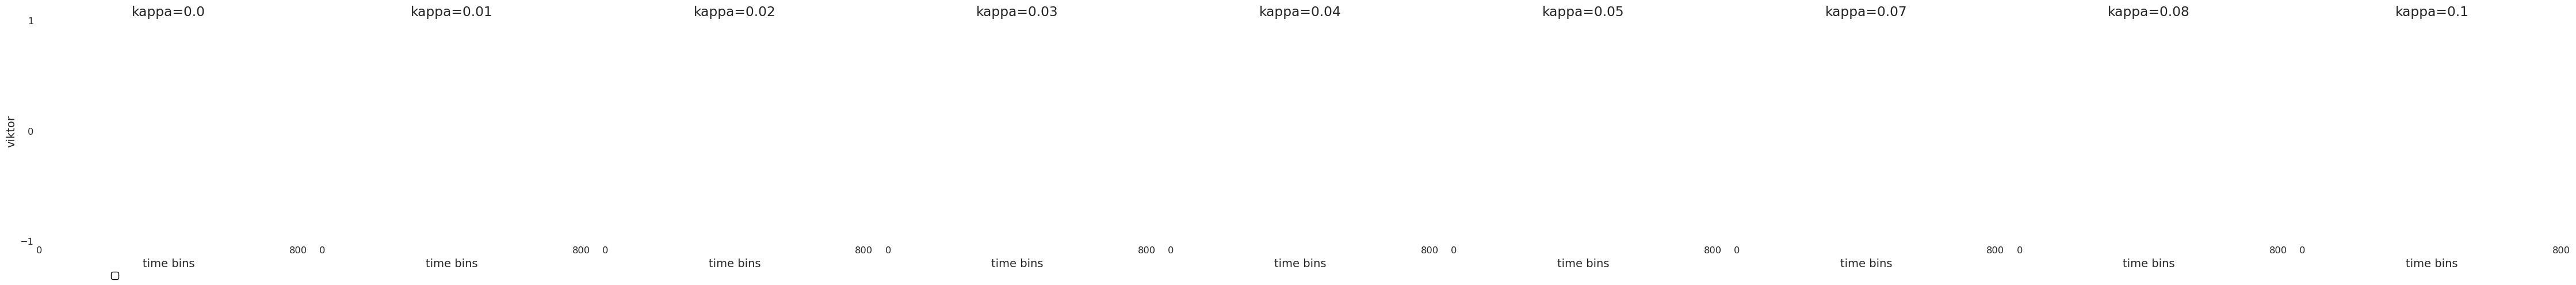

In [359]:
%%capture --no-display
# Define the custom palette
custom_palette = [
    # "#fcba03",
    "#6ffc03",  # Shades of blue
    "#033dfc",
    "#c603fc",
    '#ff5500'# Shades of green
]

styles = [
    "o",
    "*",
    's',
    's'
]

# Bin data
x_bins = 'time bins'
df_LL[x_bins] = utils.data.bin_data(df_LL, 'push times', bins = 20)
df_exp = df_LL.xs(1, level='shape', drop_level=False)
df_gamma = df_LL.xs(10, level='shape', drop_level=False)
cols = ['biased dice', 'markov chain', 'internal model']
def plot_func(df_group, conds=conds, ax=None, min_obs = 20, **kwargs):
    df_subject = df_group.loc[:,[x_bins] + cols].dropna().reset_index()
    df_subject.loc[:,cols] = df_subject.loc[:,cols].apply(lambda x: 1 + x/np.log(3))
    df_long = df_subject.melt(id_vars=x_bins, var_name="model", value_name="likelihood", value_vars=cols)

    # Filter out bins without min obs
    df_long = df_long.groupby(x_bins, as_index=False).filter(lambda g: len(g) >= min_obs)
    sns.lineplot(df_long, x = x_bins, y = 'likelihood', hue = 'model', hue_order = cols, palette = custom_palette, style = "model", markers = styles, dashes = False, ax = ax, **kwargs)

    # Plot null LL
    # ax.axhline(np.log(1/3), c = 'black', linestyle = '--', linewidth = 2, label = 'random dice LL')
    ax.set_ylim([-1,1])
    ax.set_yticks([-1,0,1])
    ax.set_xticks([0, 800])
    # ax.invert_yaxis()
    ax.set_xlabel(x_bins)
    kappa = conds['kappa']
    ax.set_title(f'kappa={kappa}')
axes = plotting.plot_variable_subplots(df_gamma, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True, 'sharex': True}, min_obs = 50, savefig = 'model_fit.png', markersize = 10, errorbar = 'se')

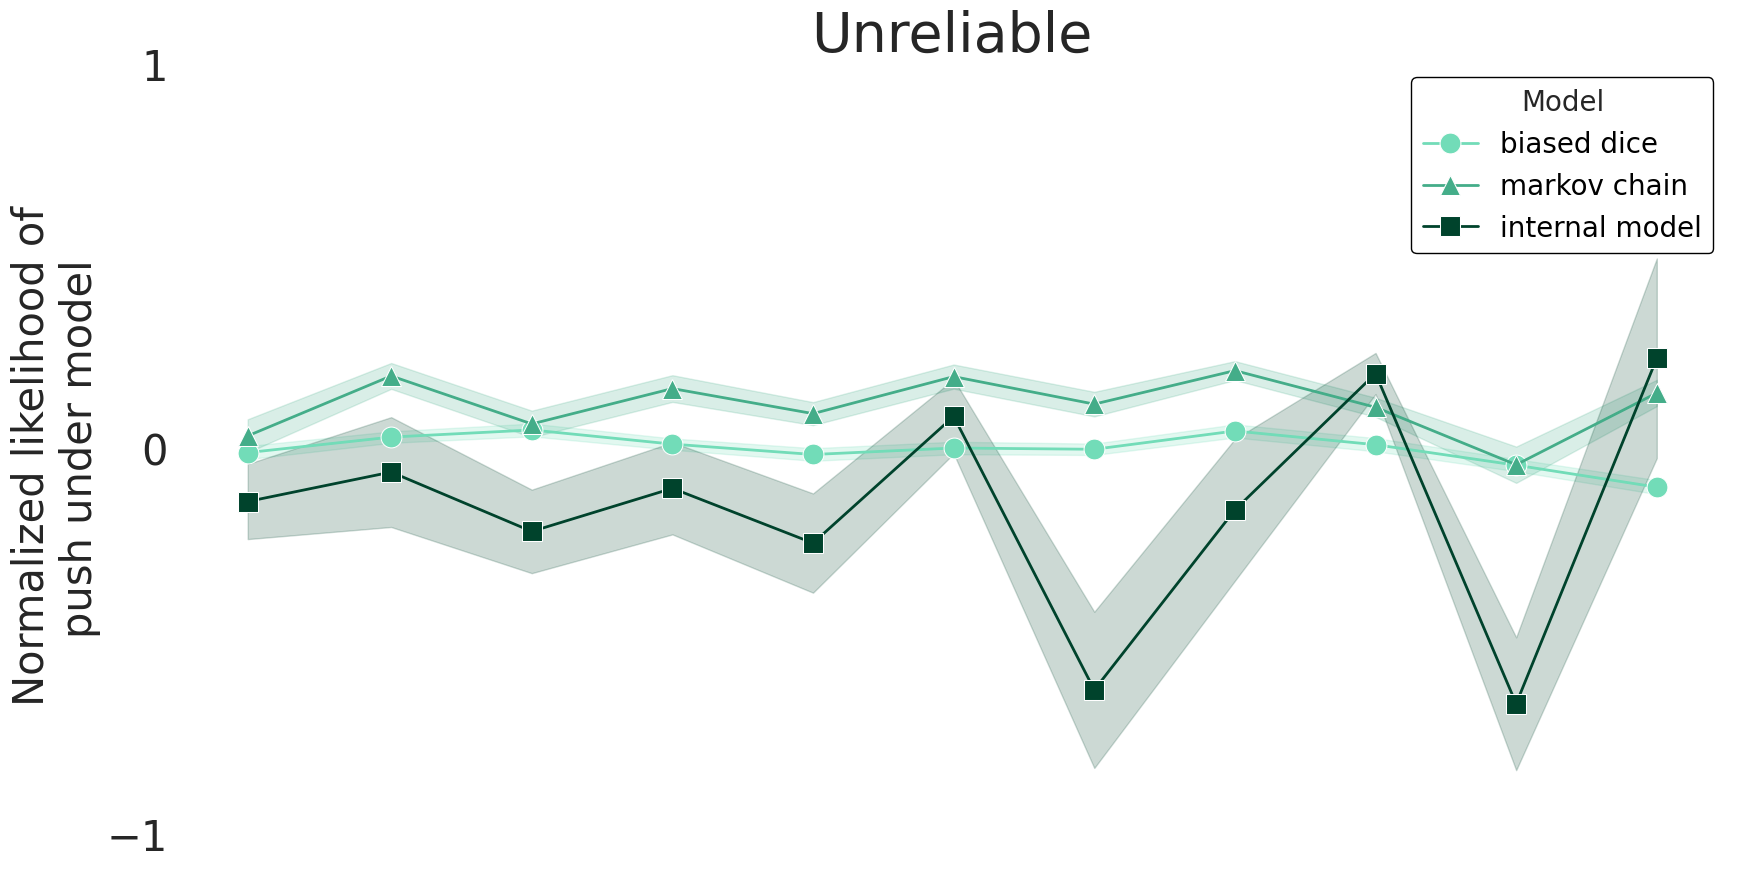

In [298]:
%%capture --no-display
# Define the custom palette
custom_palette = [
    "#72dcb8",
    "#44ad89",
    "#00432c" # Shades of green
]

styles = [
    "o",
    "^",
    's'
]

# Bin data
x_bins = 'time bins'
df_LL[x_bins] = utils.data.bin_data(df_LL, 'push times', bins = 20)
df_gamma = df_LL.xs(('viktor', 10), level=('subject', 'shape'), drop_level=False)
cols = ['biased dice', 'markov chain', 'internal model']
def plot_func(df_group, conds=conds, ax=None, min_obs = 20, **kwargs):
    df_subject = df_group.loc[:,[x_bins] + cols].dropna().reset_index()
    df_subject.loc[:,cols] = df_subject.loc[:,cols].apply(lambda x: 1 + x/np.log(3))
    df_long = df_subject.melt(id_vars=x_bins, var_name="model", value_name="likelihood", value_vars=cols)

    # Filter out bins without min obs
    df_long = df_long.groupby(x_bins, as_index=False).filter(lambda g: len(g) >= min_obs)
    sns.lineplot(df_long, x = x_bins, y = 'likelihood', hue = 'model', hue_order = cols, palette = custom_palette, style = "model", markers = styles, dashes = False, ax = ax, **kwargs)

    # Plot null LL
    # ax.axhline(np.log(1/3), c = 'black', linestyle = '--', linewidth = 2, label = 'random dice LL')
    ax.set_ylim([-1,1])
    ax.set_yticks([-1,0,1])
    ax.set_xticks([0, 800])
    # ax.invert_yaxis()
    ax.set_xlabel(x_bins)
    kappa = conds['kappa']
    ax.set_title(f'kappa={kappa}')
    return ax
conds= {'kappa': 0}
fig, ax = plt.subplots()
plot_func(utils.data.filter_df(df_gamma, conds), conds = conds, ax = ax, markersize = 15, errorbar = 'se')
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_ylabel("Normalized likelihood of \npush under model", fontsize = 30)
ax.set_xlabel("", fontsize = 30)
ax.set_xticks([])
ax.set_title("Unreliable", fontsize = 40)
plt.legend(title = 'Model', fontsize = 20, title_fontsize = 20)
#plotting.plot_variable_subplots(df_gamma, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True, 'sharex': True}, min_obs = 50, savefig = 'model_fit.png', markersize = 10, errorbar = 'se')

In [299]:
fig.savefig('model_fit_unreliable.png', bbox_inches = 'tight', facecolor = 'white')

Text(0.5, 1.0, 'Reliable')

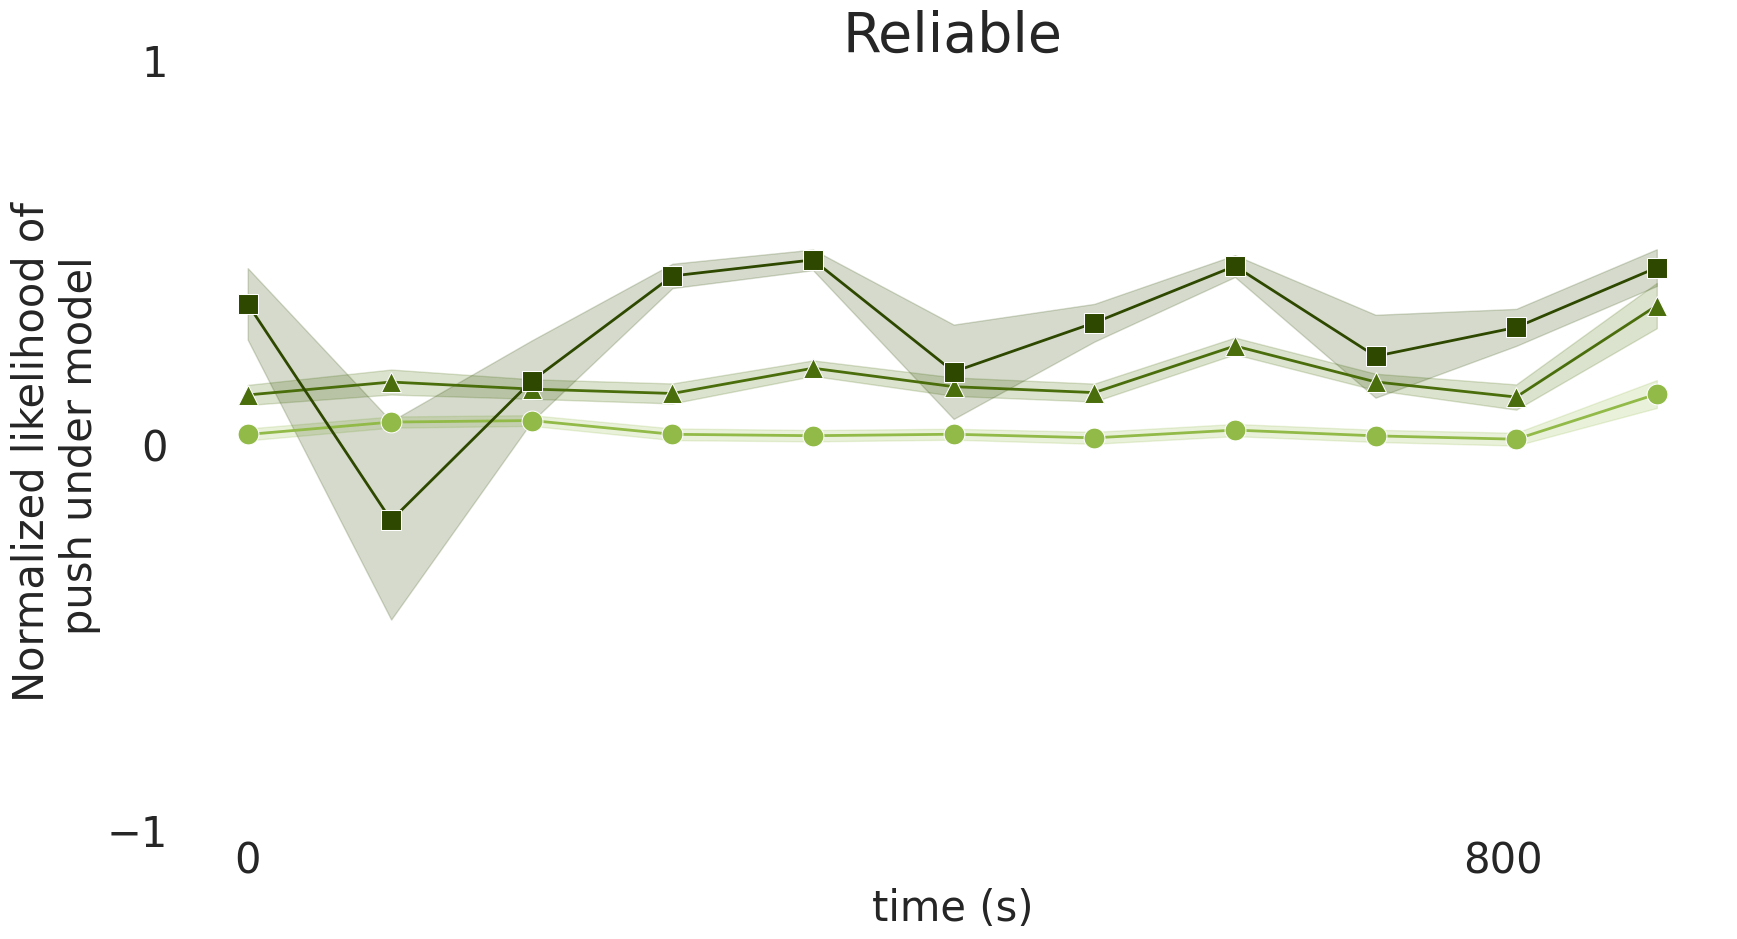

In [304]:
%%capture --no-display
# Define the custom palette
custom_palette = [
    "#92ba49",
    "#4b6e0c",
    "#2e4800"# Shades of green
]

styles = [
    "o",
    "^",
    's'
]

# Bin data
x_bins = 'time bins'
df_LL[x_bins] = utils.data.bin_data(df_LL, 'push times', bins = 20)
df_gamma = df_LL.xs(('viktor', 10), level=('subject', 'shape'), drop_level=False)
cols = ['biased dice', 'markov chain', 'internal model']
def plot_func(df_group, conds=conds, ax=None, min_obs = 20, **kwargs):
    df_subject = df_group.loc[:,[x_bins] + cols].dropna().reset_index()
    df_subject.loc[:,cols] = df_subject.loc[:,cols].apply(lambda x: 1 + x/np.log(3))
    df_long = df_subject.melt(id_vars=x_bins, var_name="model", value_name="likelihood", value_vars=cols)

    # Filter out bins without min obs
    df_long = df_long.groupby(x_bins, as_index=False).filter(lambda g: len(g) >= min_obs)
    sns.lineplot(df_long, x = x_bins, y = 'likelihood', hue = 'model', hue_order = cols, palette = custom_palette, style = "model", markers = styles, dashes = False, ax = ax, **kwargs)

    # Plot null LL
    # ax.axhline(np.log(1/3), c = 'black', linestyle = '--', linewidth = 2, label = 'random dice LL')
    ax.set_ylim([-1,1])
    ax.set_yticks([-1,0,1])
    ax.set_xticks([0, 800])
    # ax.invert_yaxis()
    ax.set_xlabel(x_bins)
    kappa = conds['kappa']
    ax.set_title(f'kappa={kappa}')
    return ax
conds= {'kappa': 0.1}
fig, ax = plt.subplots()
plot_func(utils.data.filter_df(df_gamma, conds), conds = conds, ax = ax, markersize = 15, errorbar = 'se', legend = False)
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_ylabel("Normalized likelihood of \npush under model", fontsize = 30)
ax.set_xlabel("time (s)", fontsize = 30)
ax.set_title("Reliable", fontsize = 40)
#plotting.plot_variable_subplots(df_gamma, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True, 'sharex': True}, min_obs = 50, savefig = 'model_fit.png', markersize = 10, errorbar = 'se')

In [305]:
fig.savefig('model_fit_reliable.png', bbox_inches = 'tight', facecolor = 'white')

In [141]:
fig = axes.flatten()[0].get_figure()
with plt.style.context('default'):
   fig.savefig('model_fit2.png', facecolor = 'white')

In [13]:
# Get likelihoods of fitted models
null_LL, _ = utils.data.process_blocks(df_monkey, utils.stats.null_likelihood)
biased_coin_LL, _ = utils.data.process_blocks(df_monkey, utils.stats.biased_coin_likelihood, visit_probabilities)
stay_switch_LL, _ = utils.data.process_blocks(transitions_ss, utils.stats.stay_switch_likelihood, transitions_ss_sessions)
winstay_loseswitch_LL, _ = utils.data.process_blocks(transitions1, utils.stats.mc1_likelihood, transitions1_sessions)
mc_2nd_order_LL, _ = utils.data.process_blocks(transitions2, utils.stats.generalized_markov_likelihood, transitions2_sessions);

In [14]:
utils.data.extend_df(df_monkey, null_LL, 'random dice LL')
utils.data.extend_df(df_monkey, biased_coin_LL, 'biased dice LL')
utils.data.extend_df(df_monkey, stay_switch_LL, 'stay/switch LL')
utils.data.extend_df(df_monkey, winstay_loseswitch_LL, 'win-stay/lose-switch LL')
utils.data.extend_df(df_monkey, mc_2nd_order_LL, '2nd-order win-stay/lose-switch LL');

## Compare to belief models

In [11]:
bayesian_beliefs_LL, _ = utils.data.process_blocks(df_monkey, utils.stats.beliefs_likelihood, reward_beliefs)
bayesian_beliefs_LL_shape1, _ = utils.data.process_blocks(df_monkey, utils.stats.beliefs_likelihood, reward_beliefs_shape1)
bayesian_beliefs_LL_shape10, _ = utils.data.process_blocks(df_monkey, utils.stats.beliefs_likelihood, reward_beliefs_shape10)
perfect_beliefs_LL, _ = utils.data.process_blocks(df_monkey, utils.stats.rew_prob_likelihood, reward_probabilities)
perfect_beliefs_LL_shape1, _ = utils.data.process_blocks(df_monkey, utils.stats.rew_prob_likelihood, reward_probabilities_shape1)
perfect_beliefs_LL_shape10, _ = utils.data.process_blocks(df_monkey, utils.stats.rew_prob_likelihood, reward_probabilities_shape10)
wrong_beliefs_LL, _ = utils.data.process_blocks(df_monkey, utils.stats.rew_prob_likelihood, reward_beliefs_wrong)
wrong_beliefs_LL_shape1, _ = utils.data.process_blocks(df_monkey, utils.stats.rew_prob_likelihood, reward_beliefs_wrong_shape1)
wrong_beliefs_LL_shape10, _ = utils.data.process_blocks(df_monkey, utils.stats.rew_prob_likelihood, reward_beliefs_wrong_shape10)
LL_ts, _ = utils.data.process_blocks(df, utils.stats.ts_likelihood, ts_posterior)

utils.data.extend_df(df_monkey, bayesian_beliefs_LL, 'bayesian model')
utils.data.extend_df(df_monkey, bayesian_beliefs_LL_shape1, 'bayesian model (shape 1)')
utils.data.extend_df(df_monkey, bayesian_beliefs_LL_shape10, 'bayesian model (shape 10)')
utils.data.extend_df(df_monkey, perfect_beliefs_LL, 'correct model')
utils.data.extend_df(df_monkey, perfect_beliefs_LL_shape1, 'correct model (shape 1)')
utils.data.extend_df(df_monkey, perfect_beliefs_LL_shape10, 'correct model (shape 10)')
utils.data.extend_df(df_monkey, wrong_beliefs_LL, 'wrong model')
utils.data.extend_df(df_monkey, wrong_beliefs_LL_shape1, 'wrong model (shape 1)')
utils.data.extend_df(df_monkey, wrong_beliefs_LL_shape10, 'wrong model (shape 10)')
utils.data.extend_df(df_monkey, LL_ts, 'thompson sampling')

/mnt/d/Documents/Foraging/src/foraging/utils/stats.py:145: RuntimeWarning: invalid value encountered in divide
  data = beliefs[index] / beliefs[index].sum(axis = 1, keepdims = True)


({('dylan', np.int64(1), np.int64(2)): True,
  ('dylan', np.int64(1), np.int64(3)): True,
  ('dylan', np.int64(1), np.int64(4)): True,
  ('dylan', np.int64(1), np.int64(5)): True,
  ('dylan', np.int64(1), np.int64(6)): True,
  ('dylan', np.int64(1), np.int64(7)): True,
  ('dylan', np.int64(2), np.int64(1)): True,
  ('dylan', np.int64(2), np.int64(2)): True,
  ('dylan', np.int64(2), np.int64(3)): True,
  ('dylan', np.int64(2), np.int64(4)): True,
  ('dylan', np.int64(3), np.int64(1)): True,
  ('dylan', np.int64(3), np.int64(2)): True,
  ('dylan', np.int64(3), np.int64(3)): True,
  ('dylan', np.int64(3), np.int64(4)): True,
  ('dylan', np.int64(4), np.int64(1)): True,
  ('dylan', np.int64(4), np.int64(2)): True,
  ('dylan', np.int64(4), np.int64(3)): True,
  ('dylan', np.int64(4), np.int64(4)): True,
  ('dylan', np.int64(4), np.int64(5)): True,
  ('dylan', np.int64(5), np.int64(1)): True,
  ('dylan', np.int64(5), np.int64(2)): True,
  ('dylan', np.int64(5), np.int64(3)): True,
  ('dylan'

In [357]:
train_results = []
test_results = []
for i in range(k):
    df_train, df_test = df_monkey.loc[df_monkey[f'{i+1}-fold'] == 'train'].copy(), df_monkey.loc[df_monkey[f'{i+1}-fold'] == 'test'].copy()
    train_results.append(df_train['bayesian model'])
    test_results.append(df_test['bayesian model'])
    train_results.append(df_train['bayesian model (shape 1)'])
    test_results.append(df_test['bayesian model (shape 1)'])
    train_results.append(df_train['bayesian model (shape 10)'])
    test_results.append(df_test['bayesian model (shape 10)'])

    train_results.append(df_train['correct model'])
    test_results.append(df_test['correct model'])
    train_results.append(df_train['correct model (shape 1)'])
    test_results.append(df_test['correct model (shape 1)'])
    train_results.append(df_train['correct model (shape 10)'])
    test_results.append(df_test['correct model (shape 10)'])

    train_results.append(df_train['wrong model'])
    test_results.append(df_test['wrong model'])
    train_results.append(df_train['wrong model (shape 1)'])
    test_results.append(df_test['wrong model (shape 1)'])
    train_results.append(df_train['wrong model (shape 10)'])
    test_results.append(df_test['wrong model (shape 10)'])

    train_results.append(df_train['sensory 2'])
    test_results.append(df_test['sensory 2'])
    train_results.append(df_train['sensory 2'])
    test_results.append(df_test['sensory 2'])
    train_results.append(df_train['sensory 2'])
    test_results.append(df_test['sensory 2'])


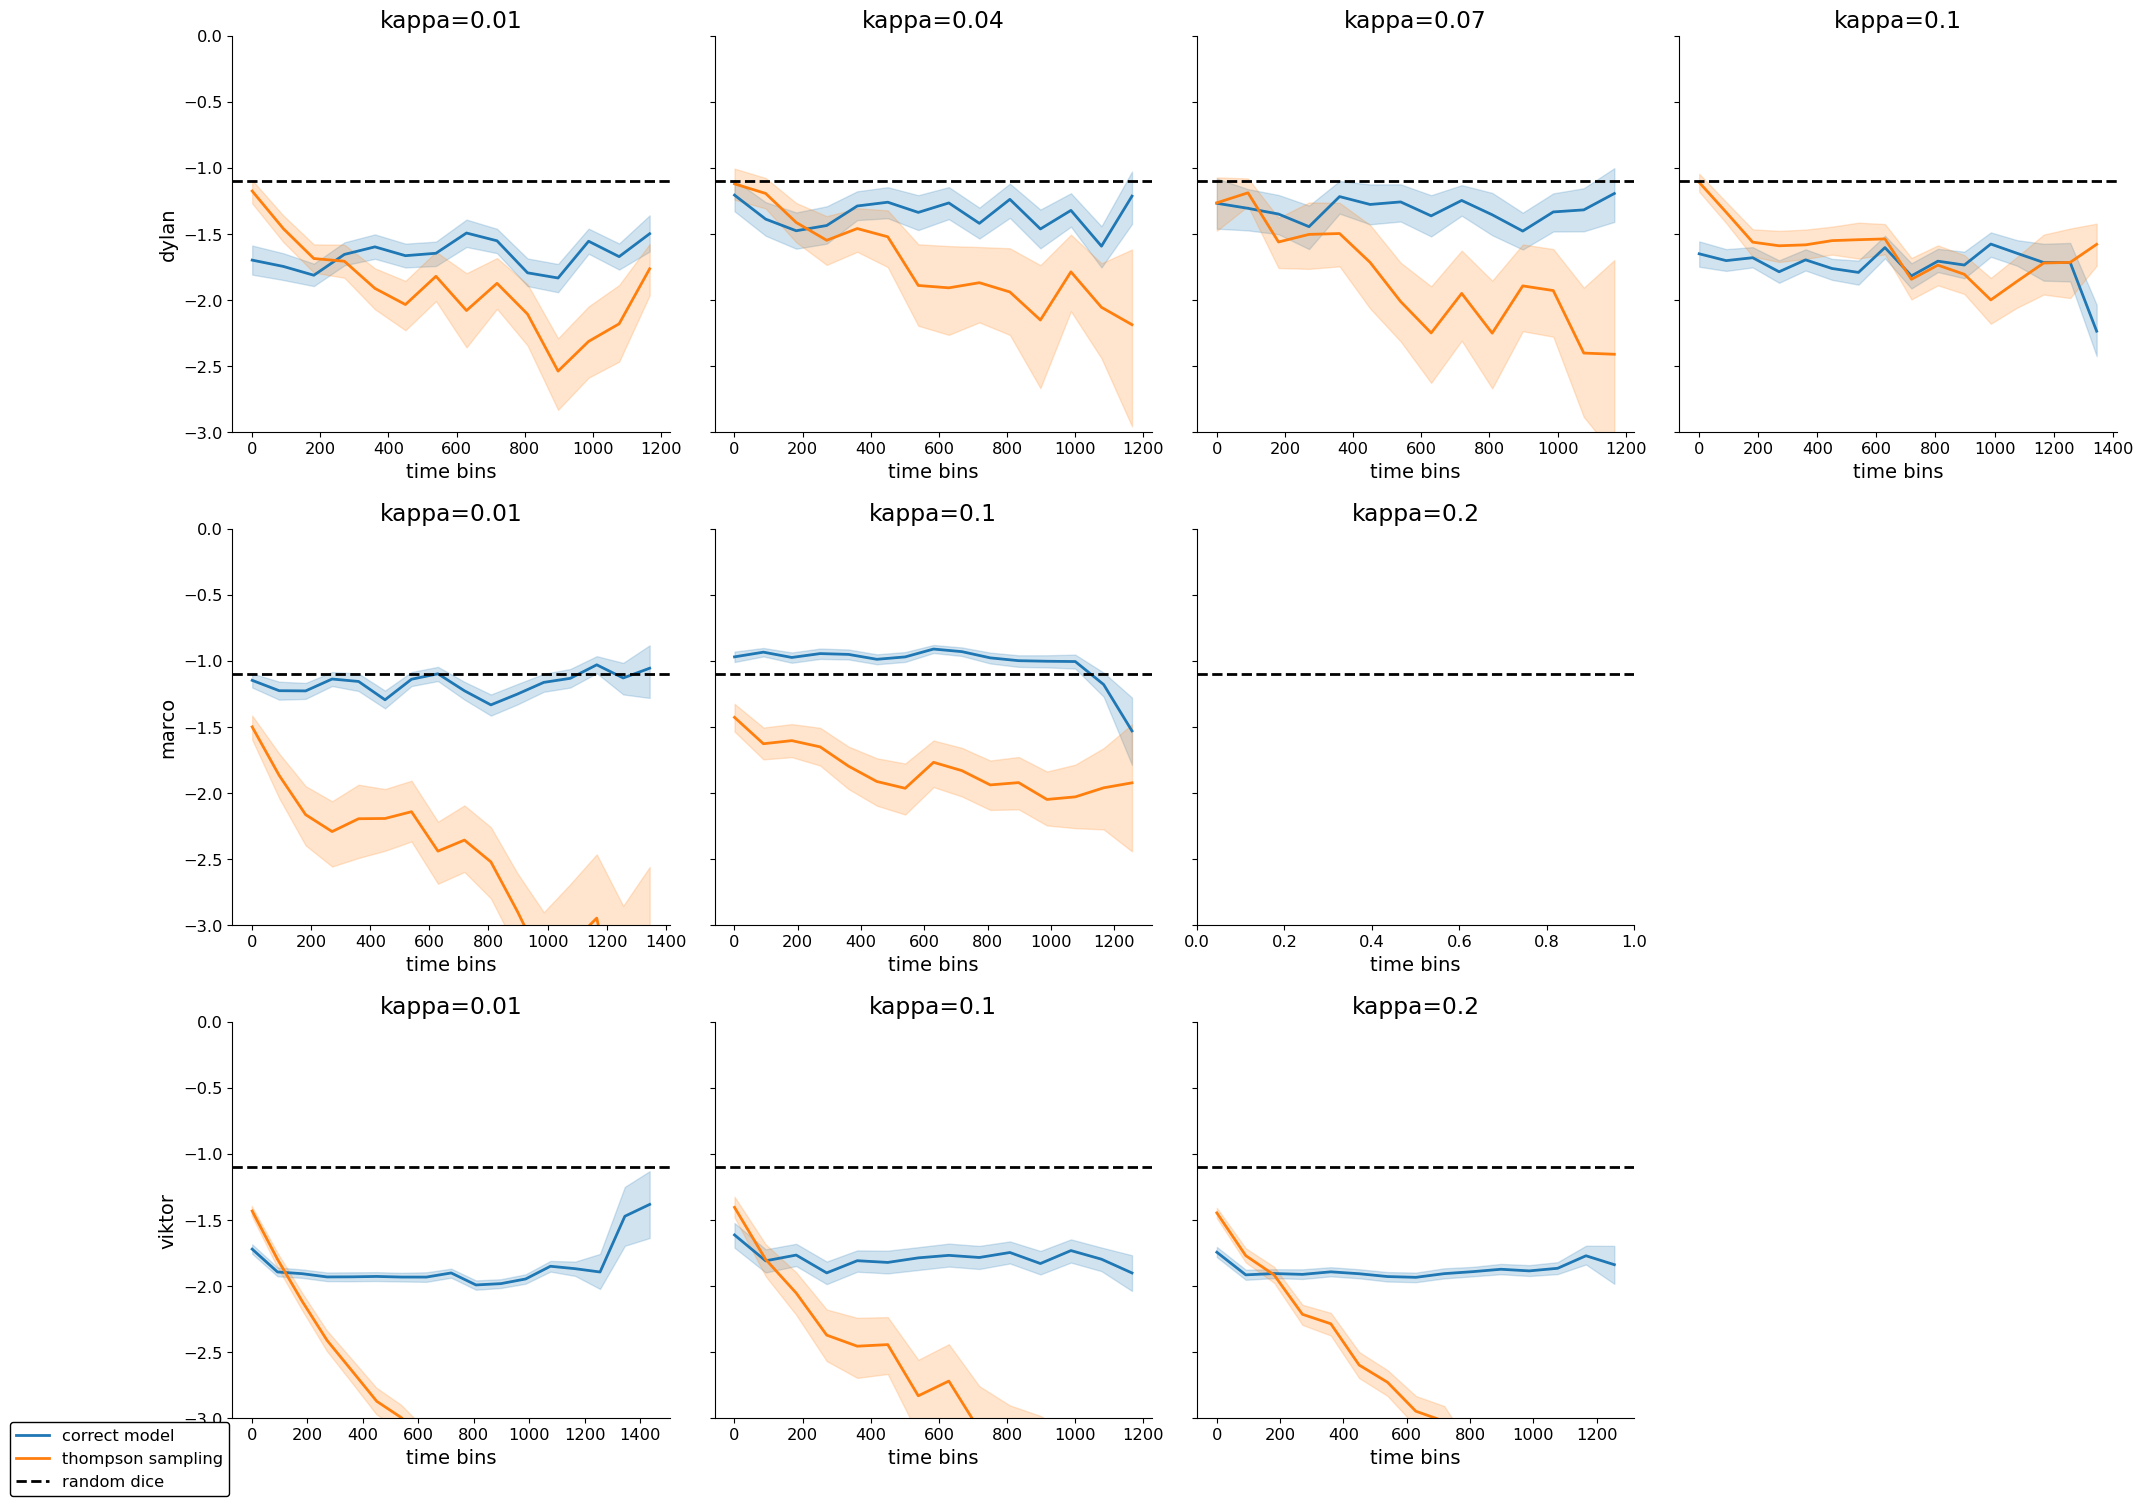

In [18]:
%%capture --no-display
# Bin data
x_bins = 'time bins'
df_monkey[x_bins] = utils.data.bin_data(df_monkey, 'push times', bins = 20)
df_exp = df_monkey.xs(1, level='shape', drop_level=False)
df_gamma = df_monkey.xs(10, level='shape', drop_level=False)
cols = ['correct model', 'thompson sampling']
def plot_func(df_group, conds=conds, ax=None, min_obs = 20, **kwargs):
    df_subject = df_group.loc[:,[x_bins] + cols].dropna().reset_index()
    df_long = df_subject.melt(id_vars=x_bins, var_name="model", value_name="likelihood", value_vars=cols)

    # Filter out bins without min obs
    df_long = df_long.groupby(x_bins, as_index=False).filter(lambda g: len(g) >= min_obs)
    sns.lineplot(df_long, x = x_bins, y = 'likelihood', hue = 'model', hue_order = cols, ax = ax, **kwargs)

    # Plot null LL
    ax.axhline(np.log(1/3), c = 'black', linestyle = '--', linewidth = 2, label = 'random dice')
    ax.set_ylim([-3,0])
    # ax.invert_yaxis()
    ax.set_xlabel(x_bins)
    kappa = conds['kappa']
    ax.set_title(f'kappa={kappa}')
axes = plotting.plot_variable_subplots(df_exp, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True}, min_obs = 50)

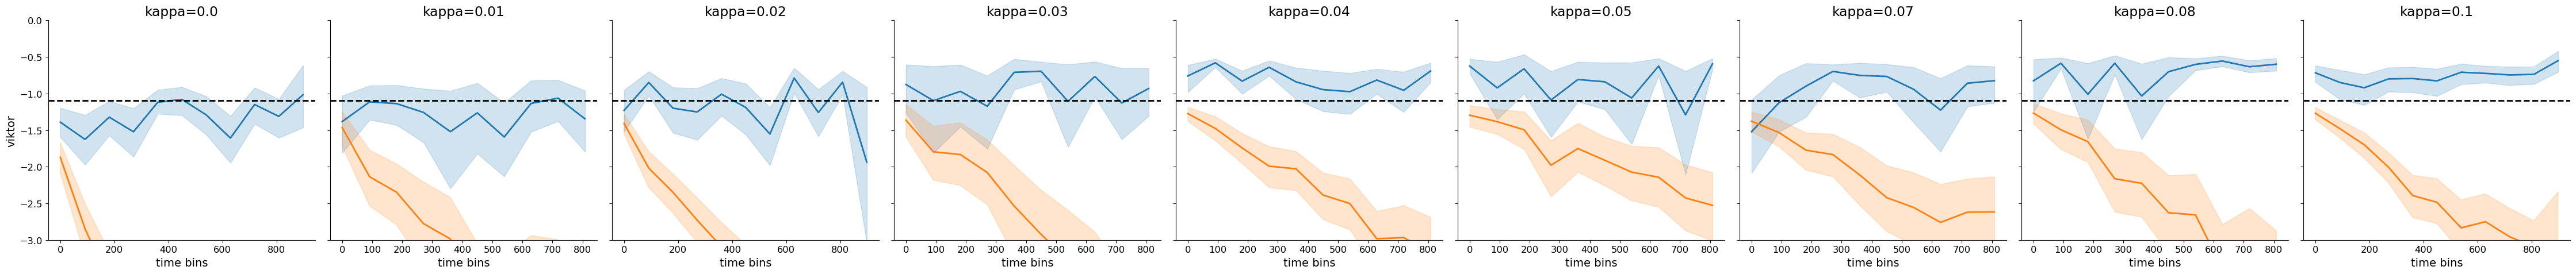

In [17]:
%%capture --no-display
axes = plotting.plot_variable_subplots(df_gamma, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True}, min_obs = 50, legend = False)

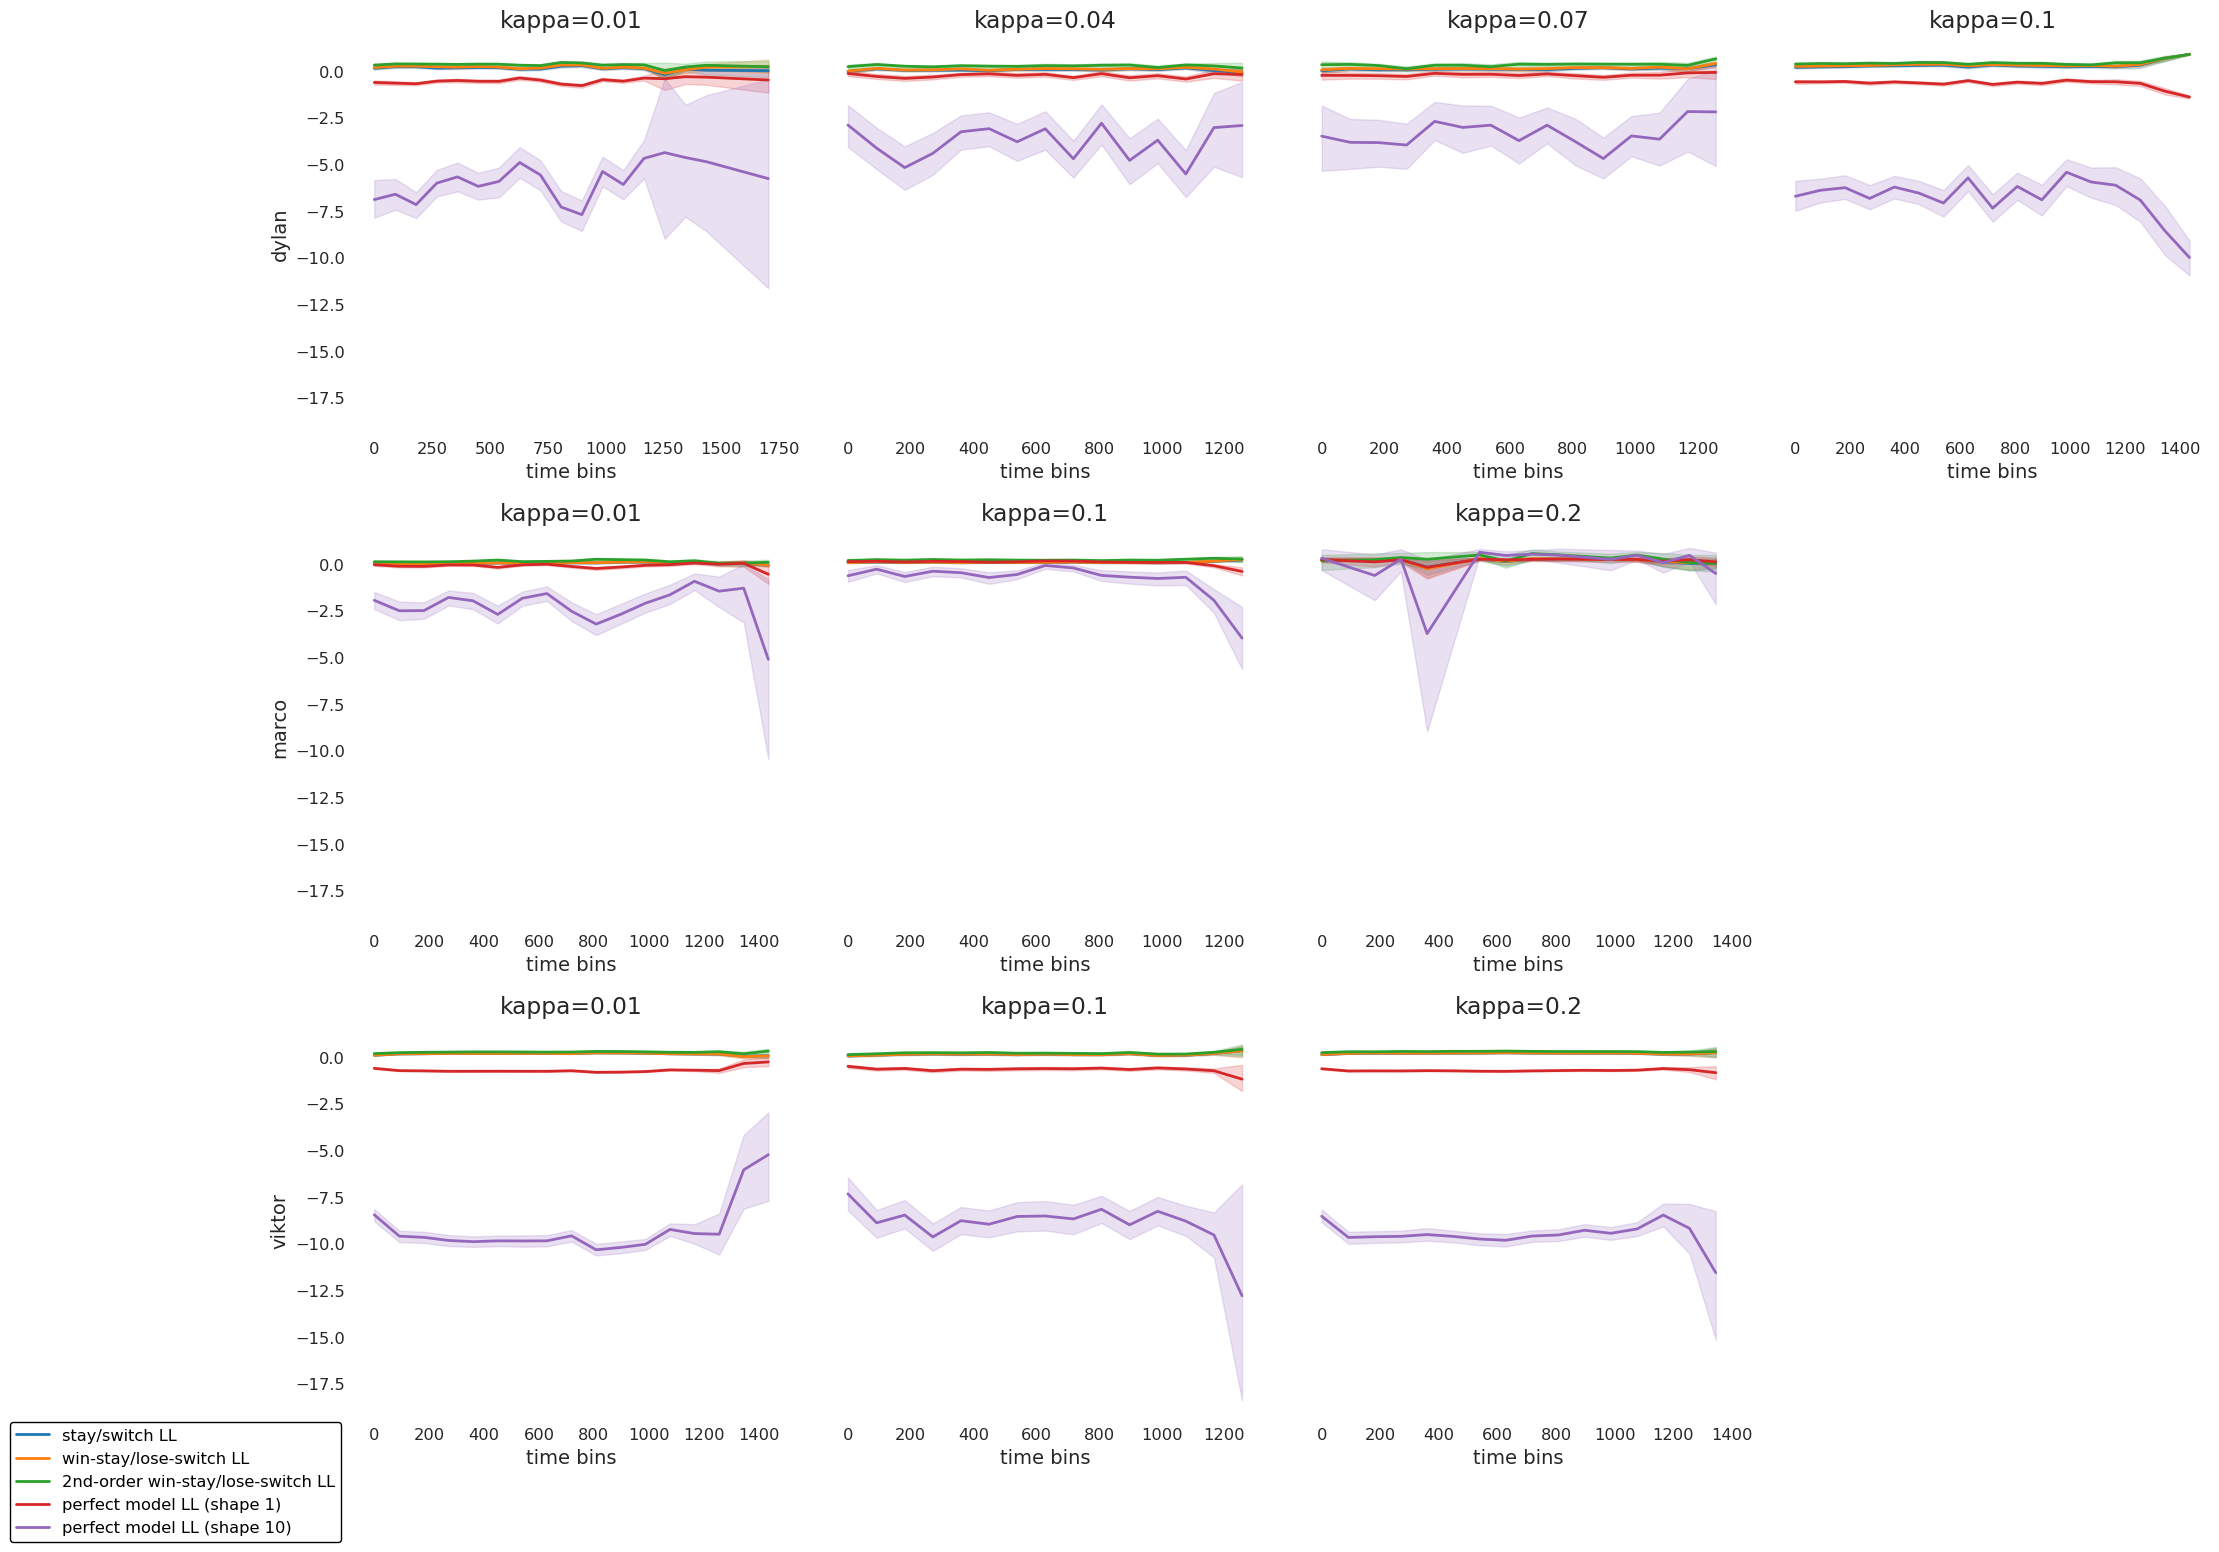

In [180]:
%%capture --no-display
def plot_func(df_group, conds=conds, ax=None, min_obs = 20, **kwargs):
    df_subject = df_group.loc[:,[x_bins] + cols].dropna().reset_index()
    df_subject.loc[:,cols] = df_subject.loc[:,cols].apply(lambda x: 1 + x/np.log(3))
    df_long = df_subject.melt(id_vars=x_bins, var_name="model", value_name="likelihood", value_vars=cols)

    # Filter out bins without min obs
    df_long = df_long.groupby(x_bins, as_index=False).filter(lambda g: len(g) >= min_obs)
    sns.lineplot(df_long, x = x_bins, y = 'likelihood', hue = 'model', hue_order = cols, ax = ax, **kwargs)

    # ax.set_ylim([-3,0])
    ax.set_xlabel(x_bins)
    kappa = conds['kappa']
    ax.set_title(f'kappa={kappa}')
axes = plotting.plot_variable_subplots(df_exp, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True})

[(-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0)]

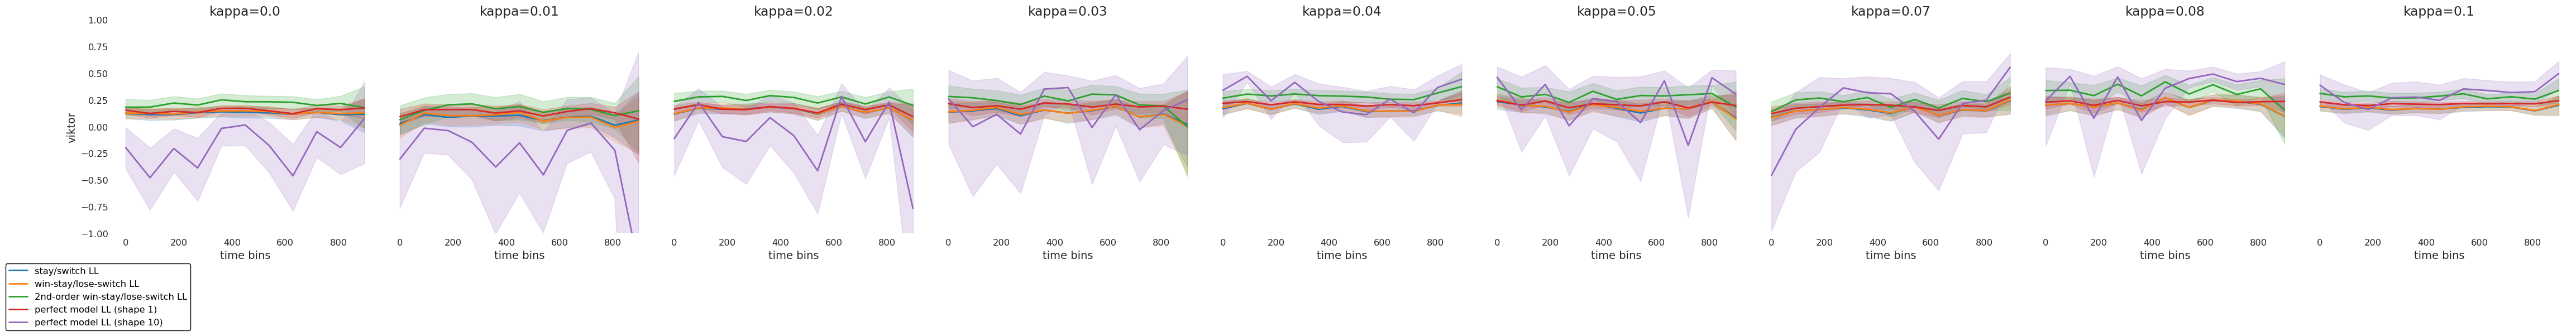

In [181]:
%%capture --no-display
axes = plotting.plot_variable_subplots(df_gamma, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True})
[ax.set_ylim([-1, 1]) for ax in axes.flatten()];

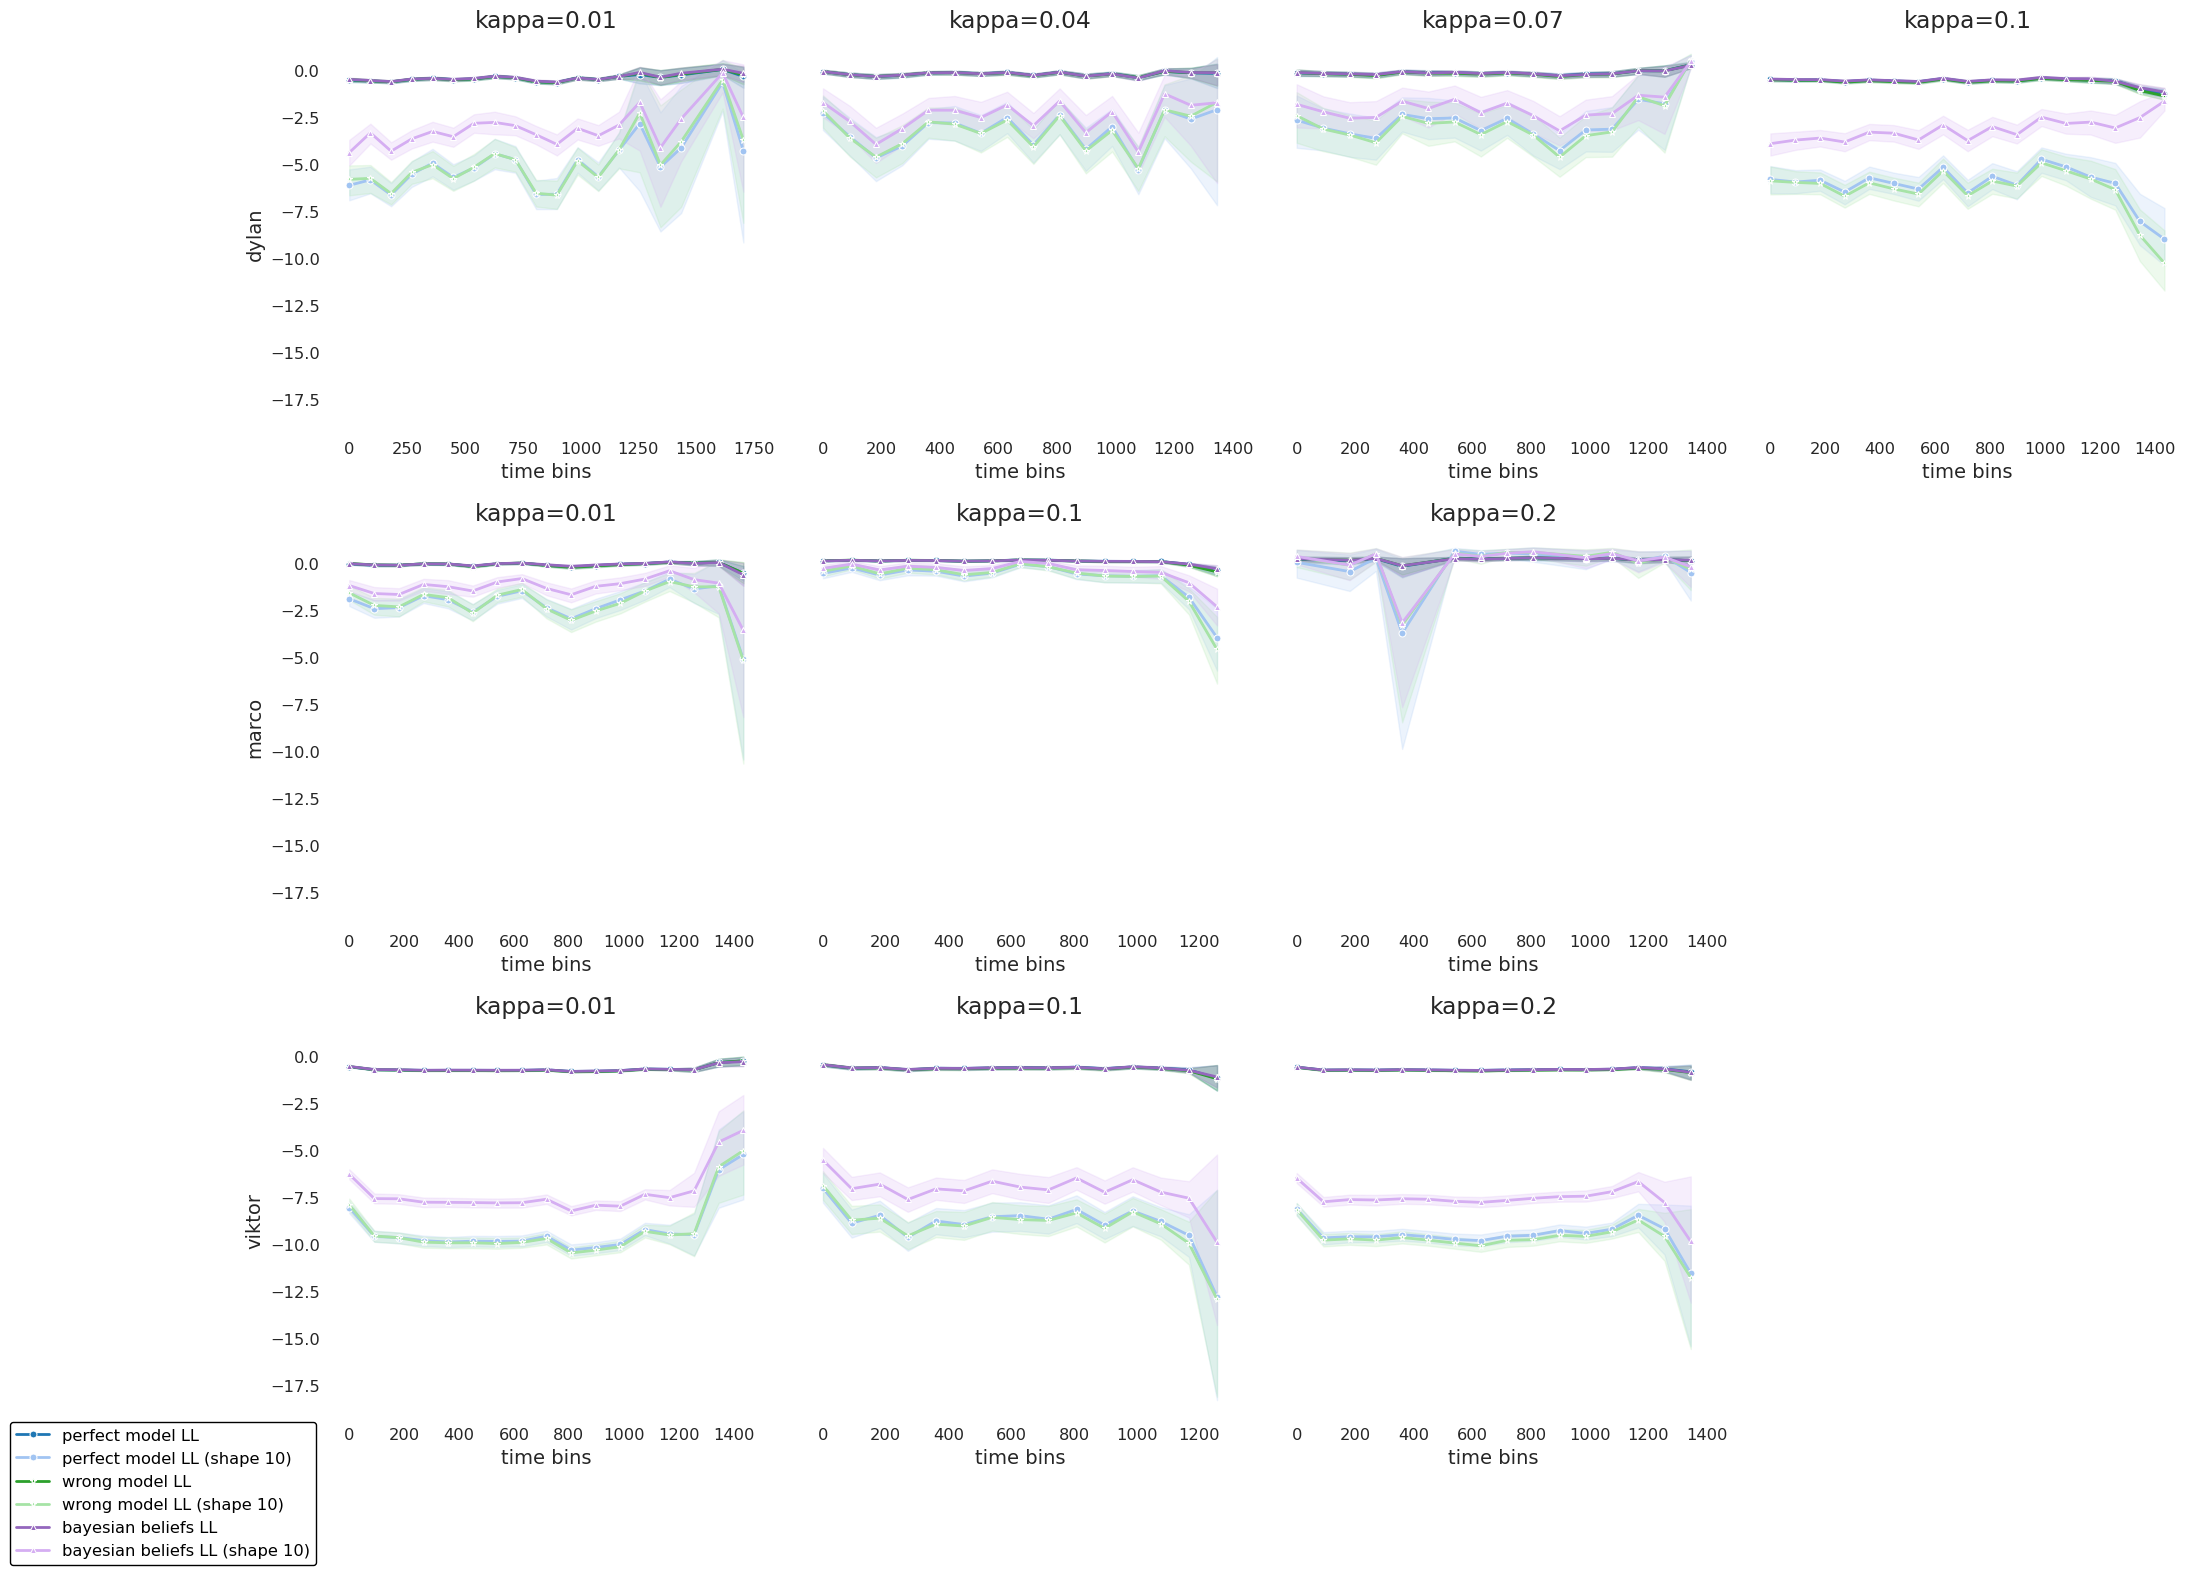

In [95]:
%%capture --no-display
from matplotlib import patches
# Define the custom palette
custom_palette = [
    "#1f77b4",
    "#a1c4f2",  # Shades of blue
    "#2ca02c",
    "#a6e3a6",  # Shades of green
    "#9467bd",
    "#d5aef2",  # Shades of purple
]

styles = [
    "o",
    "o",
    "*",
    "*",
    "^",
    "^"
]

legend_labels = ['perfect model LL', 'perfect model LL (shape 10)', 'wrong model LL', 'wrong model LL (shape 10)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 10)']

custom_legend = [
    patches.Patch(facecolor=color, label=label)
    for color, label in zip(custom_palette, legend_labels)
]

def plot_func(df_group, conds=conds, ax=None, min_obs = 20, **kwargs):
    df_subject = df_group.loc[:, [x_bins, 'perfect model LL', 'perfect model LL (shape 10)', 'wrong model LL', 'wrong model LL (shape 10)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 10)']].dropna().reset_index()
    df_subject.loc[:,['perfect model LL', 'perfect model LL (shape 10)', 'wrong model LL', 'wrong model LL (shape 10)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 10)']] = df_subject.loc[:,['perfect model LL', 'perfect model LL (shape 10)', 'wrong model LL', 'wrong model LL (shape 10)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 10)']].apply(lambda x: 1 + x/np.log(3))
    df_long = df_subject.melt(id_vars=x_bins, var_name="model", value_name="likelihood", value_vars=['perfect model LL', 'perfect model LL (shape 10)', 'wrong model LL', 'wrong model LL (shape 10)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 10)'])

    # Filter out bins without min obs
    df_long = df_long.groupby(x_bins, as_index=False).filter(lambda g: len(g) >= min_obs)
    sns.lineplot(df_long, x = x_bins, y = 'likelihood', hue = 'model', hue_order = ['perfect model LL', 'perfect model LL (shape 10)', 'wrong model LL', 'wrong model LL (shape 10)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 10)'], palette = custom_palette, style = "model", markers = styles, dashes = False, ax = ax)

    # Plot null LL
    # ax.axhline(np.log(1/3), c = 'black', linestyle = '--', linewidth = 2, label = 'random dice LL')
    ax.set_xlabel(x_bins)
    kappa = conds['kappa']
    ax.set_title(f'kappa={kappa}')
axes = plotting.plot_variable_subplots(df_exp, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True}, legend = False, global_legend = True)
# [ax.set_ylim([-1, 1]) for ax in axes.flatten()];

[(-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0),
 (-1.0, 1.0)]

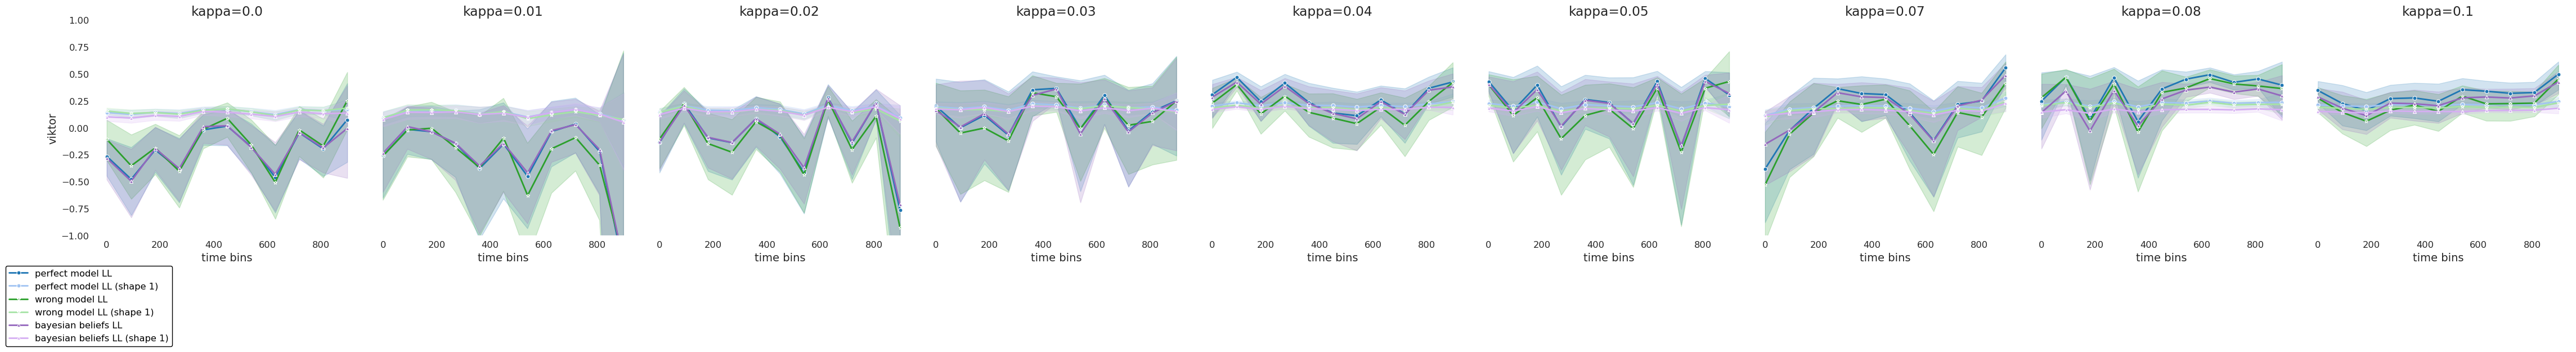

In [97]:
%%capture --no-display
from matplotlib import patches
# Define the custom palette
custom_palette = [
    "#1f77b4",
    "#a1c4f2",  # Shades of blue
    "#2ca02c",
    "#a6e3a6",  # Shades of green
    "#9467bd",
    "#d5aef2",  # Shades of purple
]

styles = [
    "o",
    "o",
    "*",
    "*",
    "^",
    "^"
]

legend_labels = ['perfect model LL', 'perfect model LL (shape 1)', 'wrong model LL', 'wrong model LL (shape 1)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 1)']

custom_legend = [
    patches.Patch(facecolor=color, label=label)
    for color, label in zip(custom_palette, legend_labels)
]

def plot_func(df_group, conds=conds, ax=None, min_obs = 20, **kwargs):
    df_subject = df_group.loc[:, [x_bins, 'perfect model LL', 'perfect model LL (shape 1)', 'wrong model LL', 'wrong model LL (shape 1)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 1)']].dropna().reset_index()
    df_subject.loc[:,['perfect model LL', 'perfect model LL (shape 1)', 'wrong model LL', 'wrong model LL (shape 1)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 1)']] = df_subject.loc[:,['perfect model LL', 'perfect model LL (shape 1)', 'wrong model LL', 'wrong model LL (shape 1)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 1)']].apply(lambda x: 1 + x/np.log(3))
    df_long = df_subject.melt(id_vars=x_bins, var_name="model", value_name="likelihood", value_vars=['perfect model LL', 'perfect model LL (shape 1)', 'wrong model LL', 'wrong model LL (shape 1)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 1)'])

    # Filter out bins without min obs
    df_long = df_long.groupby(x_bins, as_index=False).filter(lambda g: len(g) >= min_obs)
    sns.lineplot(df_long, x = x_bins, y = 'likelihood', hue = 'model', hue_order = ['perfect model LL', 'perfect model LL (shape 1)', 'wrong model LL', 'wrong model LL (shape 1)', 'bayesian beliefs LL', 'bayesian beliefs LL (shape 1)'], palette = custom_palette, style = "model", markers = styles, dashes = False, ax = ax)

    # Plot null LL
    # ax.axhline(np.log(1/3), c = 'black', linestyle = '--', linewidth = 2, label = 'random dice LL')
    ax.set_xlabel(x_bins)
    kappa = conds['kappa']
    ax.set_title(f'kappa={kappa}')
axes = plotting.plot_variable_subplots(df_gamma, plot_func, 'subject', 'kappa', fig_kwargs = {'sharey': True}, legend = False)
# plt.legend(handles = custom_legend, loc = 'upper right', bbox_to_anchor=(0.05, 0.05))
[ax.set_ylim([-1, 1]) for ax in axes.flatten()];

/tmp/ipykernel_26933/3847940157.py:17: RuntimeWarning: invalid value encountered in divide
  axes[i].plot(bins2idx.keys(), 1 - LL_stay_switch_bins[subject] / LL_random_bins[subject], label = "fit to session")


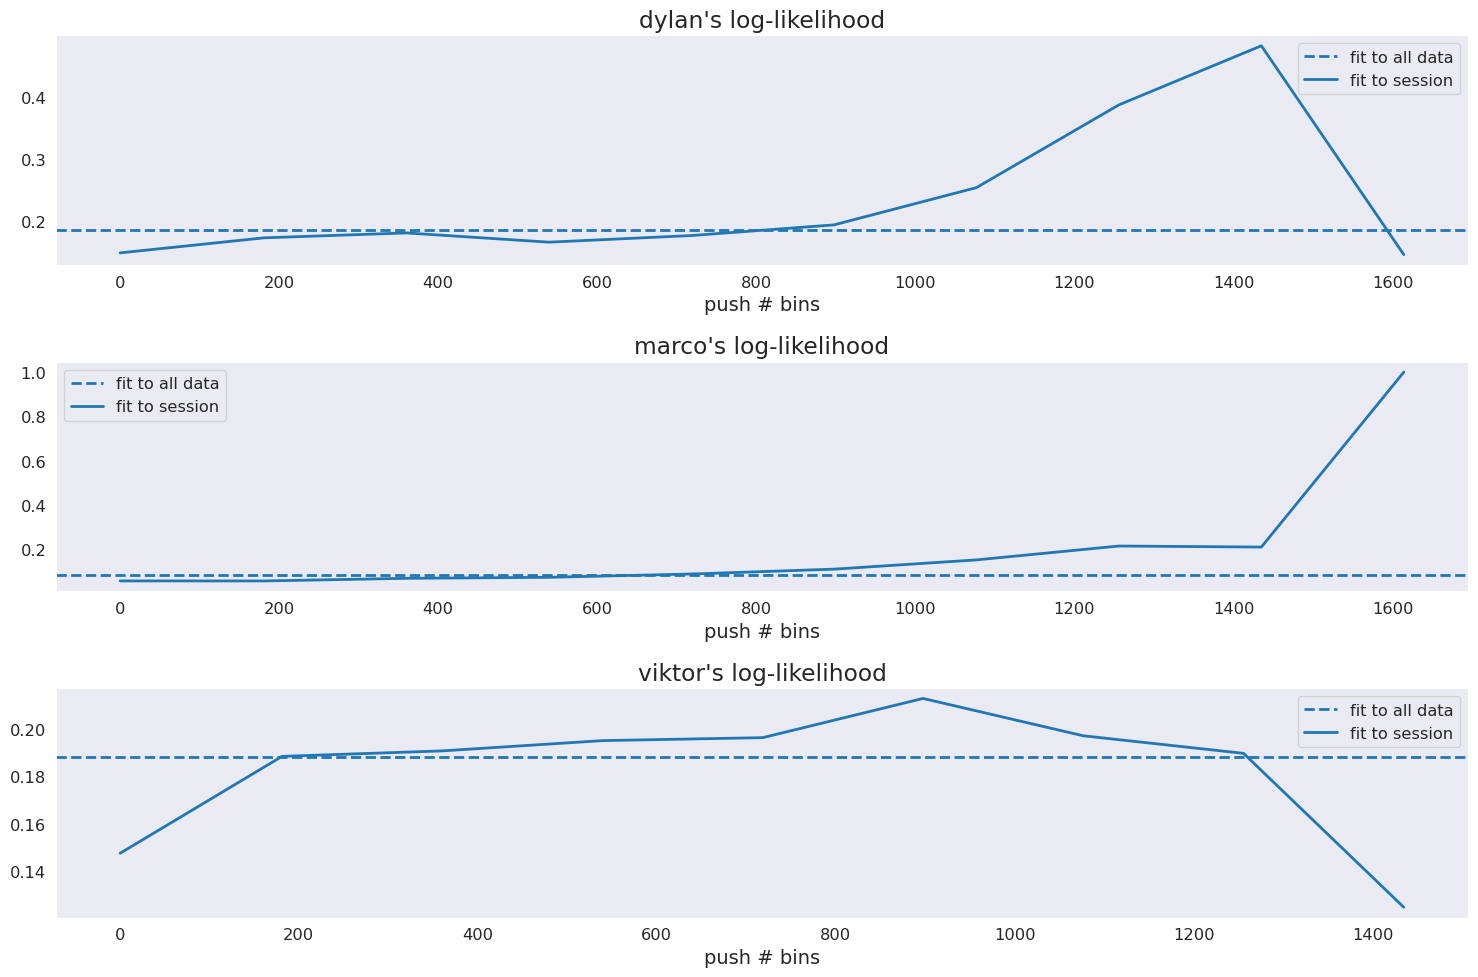

In [121]:
LL_stay_switch_bins = {k: np.zeros_like(LL_random_bins[k]) for k in monkey_subjects}
for index, g in df_monkey.groupby(['subject', 'session']):
    probs = stay_switch_probabilities[index[0]][index[1]]
    for block in g.index.unique('block'):
        df_block = df_monkey.loc[index + (block,)]
        prev_x = None
        for i, x in df_block.iterrows():
            bin = bins2idx[x['push # bins']]
            try:
                LL_stay_switch_bins[index[0]][bin] += np.log(probs[x['box rank'], x['next box']])
            except:
                continue

fig, axes = plt.subplots(len(monkey_subjects))
for i, subject in enumerate(monkey_subjects):
    axes[i].axhline(1 - LL_stay_switch[subject] / LL_random[subject], linestyle = 'dashed', label = 'fit to all data')
    axes[i].plot(bins2idx.keys(), 1 - LL_stay_switch_bins[subject] / LL_random_bins[subject], label = "fit to session")
    axes[i].set_title(f"{subject}'s log-likelihood")
    axes[i].set_xlabel("push # bins")
    axes[i].legend()
fig.tight_layout()

## Win/Stay Lose/Switch

In [122]:
df_monkey['next box'] = df_monkey['box rank'].shift(-1).astype('Int64')
df_monkey.loc[utils.data.get_blocks(df_monkey).tail(1).index, 'next box'] = np.nan
winstay_loseswitch_probabilities = {k: {j: np.zeros((2, 3, 3)) for j in df_monkey.loc[(k,)].index.unique('session')} for k in monkey_subjects}
for subject in monkey_subjects:
    df_subject = df_monkey.loc[(subject,)]
    for session in df_subject.index.unique('session'):
        df_session = df_subject.loc[(session,)]
        win = df_session['reward outcomes'] == 1
        lose = df_session['reward outcomes'] == 0
        winstay_loseswitch_probabilities[subject][session][0] = pd.crosstab(df_session.loc[lose, 'box rank'], df_session.loc[lose, 'next box'], normalize = 'index').values
        winstay_loseswitch_probabilities[subject][session][1] = pd.crosstab(df_session.loc[win, 'box rank'], df_session.loc[win, 'next box'], normalize = 'index').values

In [123]:
LL_winstay_loseswitch = {k: 0 for k in monkey_subjects}
for index, g in df_monkey.groupby(['subject', 'session']):
    probs = winstay_loseswitch_probabilities[index[0]][index[1]]
    for block in g.index.unique('block'):
        df_block = df_monkey.loc[index + (block,)]
        prev_x = None
        for i, x in df_block.iterrows():
            try:
                LL_winstay_loseswitch[index[0]] += np.log(probs[int(x['reward outcomes']),x['box rank'], x['next box']])
            except:
                continue

/tmp/ipykernel_26933/3910243042.py:17: RuntimeWarning: invalid value encountered in divide
  axes[i].plot(bins2idx.keys(), 1 - LL_winstay_loseswitch_bins[subject] / LL_random_bins[subject], label = "fit to session")


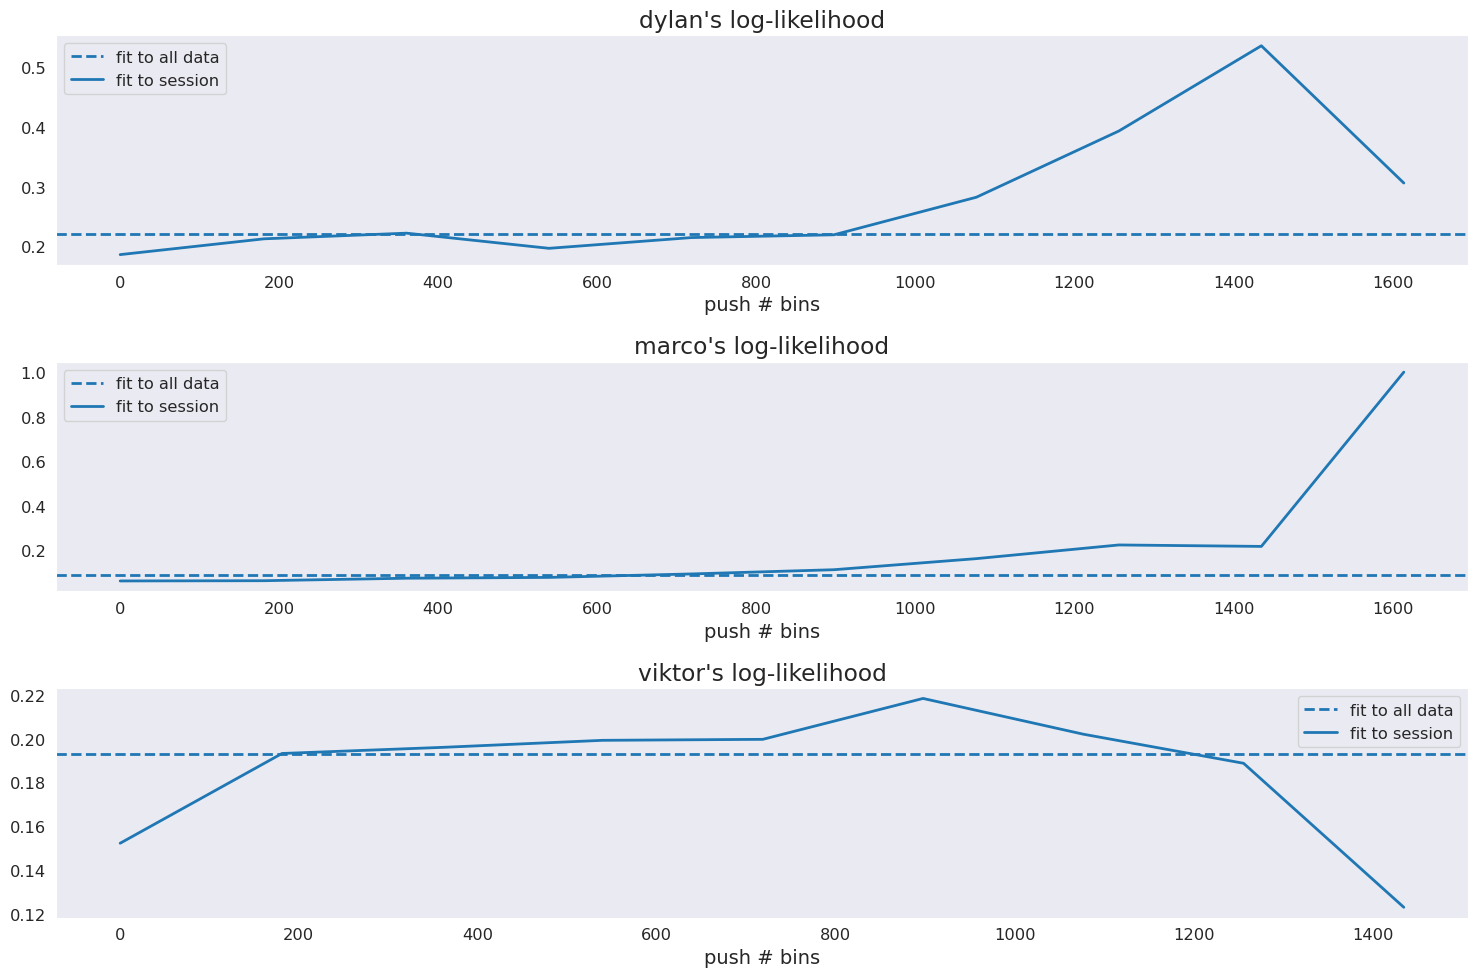

In [124]:
LL_winstay_loseswitch_bins = {k: np.zeros_like(LL_random_bins[k]) for k in monkey_subjects}
for index, g in df_monkey.groupby(['subject', 'session']):
    probs = winstay_loseswitch_probabilities[index[0]][index[1]]
    for block in g.index.unique('block'):
        df_block = df_monkey.loc[index + (block,)]
        prev_x = None
        for i, x in df_block.iterrows():
            bin = bins2idx[x['push # bins']]
            try:
                LL_winstay_loseswitch_bins[index[0]][bin] += np.log(probs[int(x['reward outcomes']), x['box rank'], x['next box']])
            except:
                continue

fig, axes = plt.subplots(len(monkey_subjects))
for i, subject in enumerate(monkey_subjects):
    axes[i].axhline(1 - LL_winstay_loseswitch[subject] / LL_random[subject], linestyle = 'dashed', label = 'fit to all data')
    axes[i].plot(bins2idx.keys(), 1 - LL_winstay_loseswitch_bins[subject] / LL_random_bins[subject], label = "fit to session")
    axes[i].set_title(f"{subject}'s log-likelihood")
    axes[i].set_xlabel("push # bins")
    axes[i].legend()
fig.tight_layout()

## Model Comparison

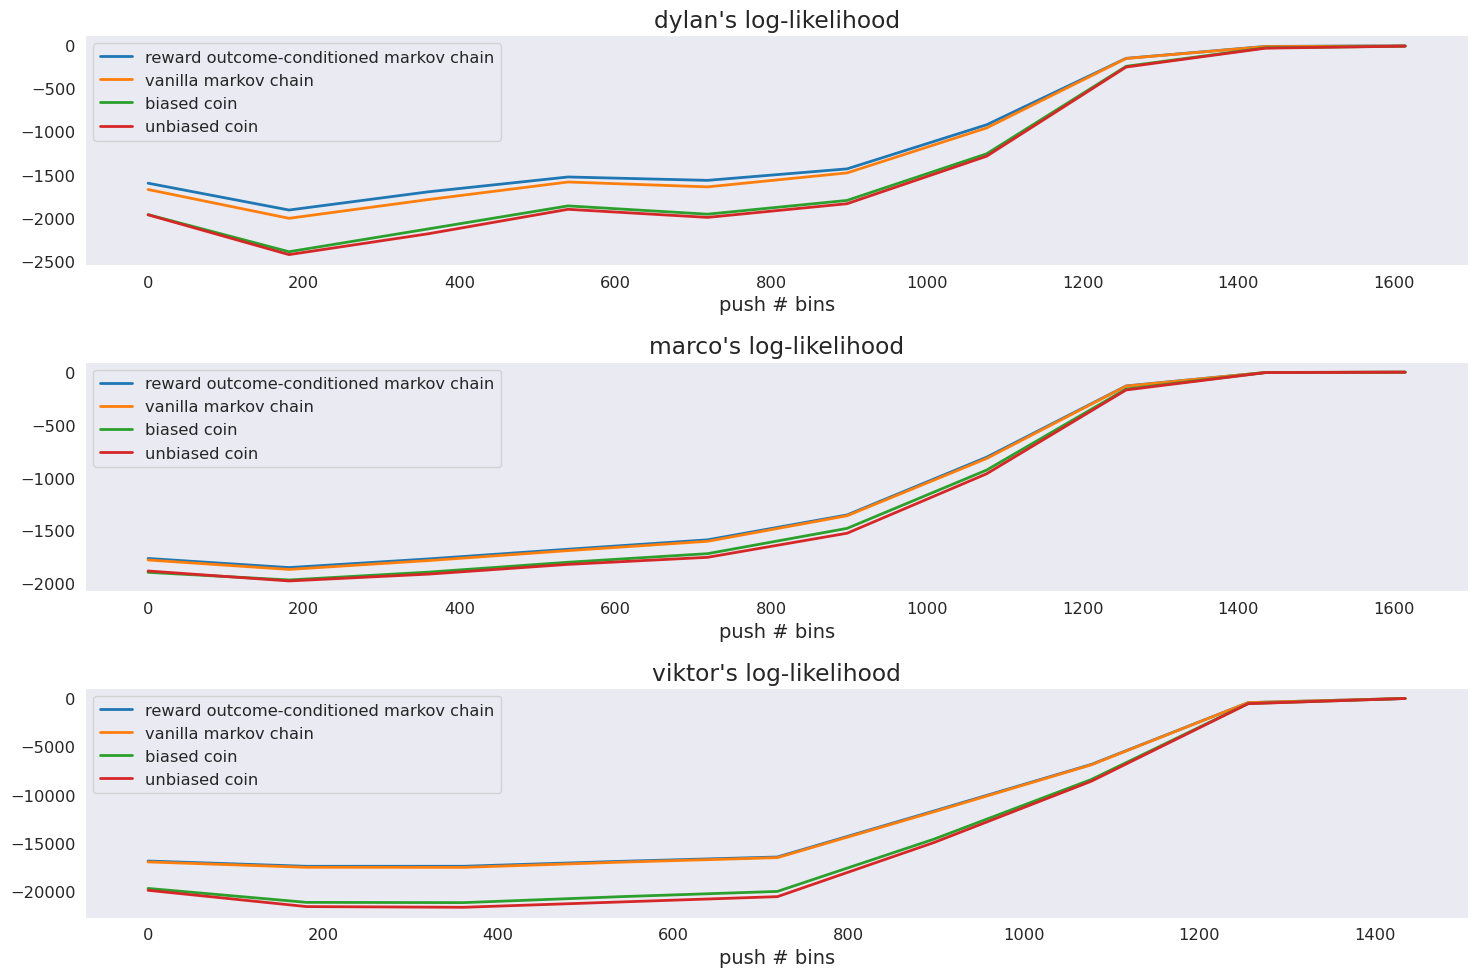

In [125]:
fig, axes = plt.subplots(len(monkey_subjects))
for i, subject in enumerate(monkey_subjects):
    nonzero = np.nonzero(LL_random_bins[subject])[0]
    x = np.array(list(bins2idx.keys()))[nonzero]
    axes[i].plot(x, LL_winstay_loseswitch_bins[subject][nonzero], label = "reward outcome-conditioned markov chain")
    axes[i].plot(x, LL_stay_switch_bins[subject][nonzero], label = "vanilla markov chain")
    axes[i].plot(x, LL_visit_bins[subject][nonzero], label = "biased coin")
    axes[i].plot(x, LL_random_bins[subject][nonzero], label = "unbiased coin")
    axes[i].set_title(f"{subject}'s log-likelihood")
    axes[i].set_xlabel("push # bins")
    axes[i].legend()
fig.tight_layout()

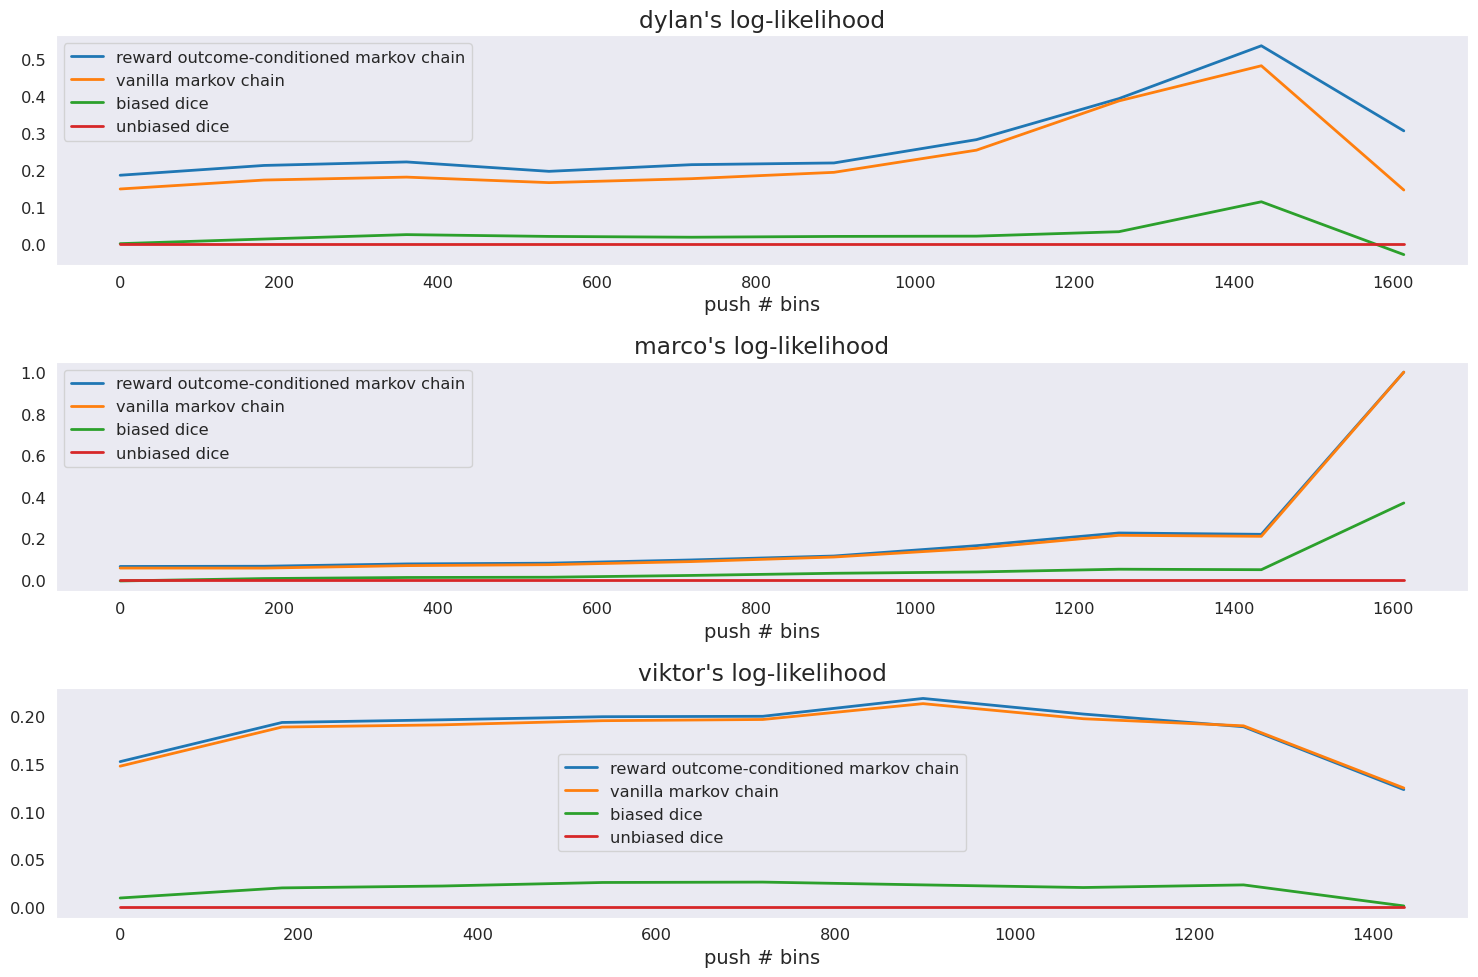

In [127]:
fig, axes = plt.subplots(len(monkey_subjects))
for i, subject in enumerate(monkey_subjects):
    nonzero = np.nonzero(LL_random_bins[subject])[0]
    x = np.array(list(bins2idx.keys()))[nonzero]
    axes[i].plot(x, 1 - LL_winstay_loseswitch_bins[subject][nonzero]/LL_random_bins[subject][nonzero], label = "reward outcome-conditioned markov chain")
    axes[i].plot(x, 1 - LL_stay_switch_bins[subject][nonzero]/LL_random_bins[subject][nonzero], label = "vanilla markov chain")
    axes[i].plot(x, 1 - LL_visit_bins[subject][nonzero]/LL_random_bins[subject][nonzero], label = "biased dice")
    axes[i].plot(x, 1 - LL_random_bins[subject][nonzero]/LL_random_bins[subject][nonzero], label = "unbiased dice")
    axes[i].set_title(f"{subject}'s log-likelihood")
    axes[i].set_xlabel("push # bins")
    axes[i].legend()
fig.tight_layout()

## Sensory model

In [56]:
reward_intervals, err = utils.data.process_blocks(df_monkey, utils.beliefs.get_concurrent_reward_intervals,use_tqdm=True)

100%|██████████| 588/588 [00:00<00:00, 686.56it/s]


In [76]:
push_rew_int_diff, err = utils.data.process_blocks(df_monkey, utils.beliefs.get_push_reward_interval_diff,use_tqdm=True)

100%|██████████| 581/581 [00:01<00:00, 531.22it/s]


In [59]:
sensory_LL, _ = utils.data.process_blocks(df_monkey, utils.stats.sensory_likelihood, reward_intervals)
utils.data.extend_df(df_monkey, sensory_LL, 'sensory')

({('dylan', np.int64(1), np.int64(2)): True,
  ('dylan', np.int64(1), np.int64(3)): True,
  ('dylan', np.int64(1), np.int64(4)): True,
  ('dylan', np.int64(1), np.int64(5)): True,
  ('dylan', np.int64(1), np.int64(6)): True,
  ('dylan', np.int64(1), np.int64(7)): True,
  ('dylan', np.int64(2), np.int64(1)): True,
  ('dylan', np.int64(2), np.int64(2)): True,
  ('dylan', np.int64(2), np.int64(3)): True,
  ('dylan', np.int64(2), np.int64(4)): True,
  ('dylan', np.int64(3), np.int64(1)): True,
  ('dylan', np.int64(3), np.int64(2)): True,
  ('dylan', np.int64(3), np.int64(3)): True,
  ('dylan', np.int64(3), np.int64(4)): True,
  ('dylan', np.int64(4), np.int64(1)): True,
  ('dylan', np.int64(4), np.int64(2)): True,
  ('dylan', np.int64(4), np.int64(3)): True,
  ('dylan', np.int64(4), np.int64(4)): True,
  ('dylan', np.int64(4), np.int64(5)): True,
  ('dylan', np.int64(5), np.int64(1)): True,
  ('dylan', np.int64(5), np.int64(2)): True,
  ('dylan', np.int64(5), np.int64(3)): True,
  ('dylan'

In [77]:
sensory_LL, _ = utils.data.process_blocks(df_monkey, utils.stats.sensory_likelihood, push_rew_int_diff)
utils.data.extend_df(df_monkey, sensory_LL, 'sensory 2')

/mnt/d/Documents/Foraging/src/foraging/utils/stats.py:146: RuntimeWarning: invalid value encountered in divide
  df['bins'] = data.bin_data(df, x, bins)
/mnt/d/Documents/Foraging/src/foraging/utils/stats.py:147: RuntimeWarning: divide by zero encountered in log
  subjects = df.index.unique('subject')


({('dylan', np.int64(1), np.int64(2)): True,
  ('dylan', np.int64(1), np.int64(3)): True,
  ('dylan', np.int64(1), np.int64(4)): True,
  ('dylan', np.int64(1), np.int64(5)): True,
  ('dylan', np.int64(1), np.int64(6)): True,
  ('dylan', np.int64(1), np.int64(7)): True,
  ('dylan', np.int64(2), np.int64(1)): True,
  ('dylan', np.int64(2), np.int64(2)): True,
  ('dylan', np.int64(2), np.int64(3)): True,
  ('dylan', np.int64(2), np.int64(4)): True,
  ('dylan', np.int64(3), np.int64(1)): True,
  ('dylan', np.int64(3), np.int64(2)): True,
  ('dylan', np.int64(3), np.int64(3)): True,
  ('dylan', np.int64(3), np.int64(4)): True,
  ('dylan', np.int64(4), np.int64(1)): True,
  ('dylan', np.int64(4), np.int64(2)): True,
  ('dylan', np.int64(4), np.int64(3)): True,
  ('dylan', np.int64(4), np.int64(4)): True,
  ('dylan', np.int64(4), np.int64(5)): True,
  ('dylan', np.int64(5), np.int64(1)): True,
  ('dylan', np.int64(5), np.int64(2)): True,
  ('dylan', np.int64(5), np.int64(3)): True,
  ('dylan'